<img src = "https://drive.google.com/uc?export=view&id=14reVO1X6LsjqJ3cFgoeHxxddZVGfZn3t" alt = "Encabezado MLDS" width = "100%">  </img>

##Integrantes

- Adriana Valderrama <adrianavalderrama11@gmail.com>
- Luis Felipe Tolosa <ltolosas@unal.edu.co>
- Michael Betancourt <msbetancourtge@unal.edu.co>

# **Entendimiento y Preparación de los Datos**
---

Este notebook es una plantilla que le puede servir como guía para el segundo entregable del proyecto aplicado.

## **1. Análisis Exploratorio de los Datos**
---

Normalmente en el análisis exploratorio, se trata de dar respuesta a los siguientes elementos:

### **1.1. Resumen General**
---

- ¿Cuántos documentos tiene el dataset?
- ¿En qué formato están guartdados los datos?
- ¿Qué tamaño en MB tiene el conjunto?

### ¿Cuántos documentos tiene el dataset?
El conjunto de datos unificado se construye a partir de tres fuentes principales: datos de mercado (Yahoo Finance), variables macroeconómicas y un corpus de comunicados de la Reserva Federal (FED). Como indicamos en la pasada entrega, para el entrenamiento del modelo LSTM se consideran secuencias temporales de los últimos 12 a 24 meses en frecuencia mensual.

### ¿En qué formato están guardados los datos?
Los datos se manejan en múltiples formatos antes de ser unificados: los comunicados de la FED se procesan inicialmente mediante scraping, mientras que los datos financieros y macroeconómicos se estructuran finalmente en un Dataset Unificado (Multivariate Time Series) para ser procesados por la red neuronal.

### ¿Qué tamaño en MB tiene el conjunto?
El tamaño total en megabytes del conjunto de datos final se especifica en la sección de carga de datos a continuación; es importante recalcar que el pipeline de datos incluye la recolección de series históricas y el procesamiento de texto mediante NLP.

El tamaño total es de 5.44 MB


#### **1. FED FOMC STATEMENTS**

In [1]:
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.5/343.5 kB 5.7 MB/s eta 0:00:00


In [2]:
import io
import re
import time
import unicodedata
import requests
import pandas as pd
import pypdf
import sys
from urllib.parse import urljoin
from bs4 import BeautifulSoup

# --- Configuración extraída de tu sugerencia ---
HEADERS = {"User-Agent": "Mozilla/5.0"}
BASE = "https://www.federalreserve.gov"
CAL_URL = "https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm"
STATEMENT_PDF_RE = re.compile(r"^https?://www\.federalreserve\.gov/monetarypolicy/files/monetary(\d{8})a(\d+)\.pdf$", re.IGNORECASE)

# --- Funciones de Limpieza y Extracción ---
def extract_text_from_pdf_bytes(pdf_bytes):
    reader = pypdf.PdfReader(io.BytesIO(pdf_bytes))
    return "\n".join([page.extract_text() or "" for page in reader.pages]).strip()

def keep_statement_only(raw_text):
    # Heurística para cortar notas de implementación
    low = raw_text.lower()
    headers = ["implementation note", "implementation notes", "information received"]
    for h in headers:
        pos = low.find(h)
        if pos != -1: return raw_text[:pos].strip()
    return raw_text.strip()

# --- Ejecución Principal ---
def download_fed_corpus_full():
    print("🔍 Escaneando calendario de la FED en busca de PDFs...")
    r = requests.get(CAL_URL, headers=HEADERS)
    soup = BeautifulSoup(r.text, "html.parser")

    urls = sorted(set([urljoin(BASE, a["href"].strip()) for a in soup.find_all("a", href=True) if STATEMENT_PDF_RE.match(urljoin(BASE, a["href"].strip()))]))

    rows = []
    print(f"📥 Descargando y procesando {len(urls)} documentos...")

    with requests.Session() as session:
        for url in urls:
            try:
                res = session.get(url, headers=HEADERS, timeout=30)
                raw_text = extract_text_from_pdf_bytes(res.content)
                clean_text = keep_statement_only(raw_text)

                rows.append({
                    "date": re.search(r"(\d{8})", url).group(1),
                    "url": url,
                    "content": clean_text
                })
                time.sleep(0.1) # Respeto al servidor
            except: continue

    df_fed = pd.DataFrame(rows)

    # --- Persistencia en Colab ---
    df_fed.to_csv("fed_corpus_data.csv", index=False)

    # --- Cálculo de Tamaño ---
    total_string = df_fed.to_string()
    size_mb = sys.getsizeof(total_string) / (1024 * 1024)

    print(f"✅ Corpus guardado como 'fed_corpus_data.csv'")
    print(f"📊 Tamaño final del Corpus FED: {size_mb:.4f} MB")
    return size_mb

fed_size_mb = download_fed_corpus_full()

🔍 Escaneando calendario de la FED en busca de PDFs...
📥 Descargando y procesando 43 documentos...
✅ Corpus guardado como 'fed_corpus_data.csv'
📊 Tamaño final del Corpus FED: 0.6515 MB


In [3]:
import yfinance as yf

def download_market_data():
    # Tickers reales del proyecto según el notebook
    tickers = ["AMD", "GOOGL", "AGG", "XOM", "JNJ", "WMT", "CM", "DUK", "BNS"]

    print(f"📈 Descargando datos históricos para {len(tickers)} activos...")

    # Descarga desde 2015 para tener suficiente historia para la LSTM
    df_market = yf.download(tickers, start="1970-01-01", end="2024-03-31")

    # --- Persistencia en Colab ---
    df_market.to_csv("market_data.csv")

    # --- Cálculo de Tamaño ---
    # memory_usage(deep=True) es lo más preciso para DataFrames de pandas
    usage_bytes = df_market.memory_usage(deep=True).sum()
    size_mb = usage_bytes / (1024 * 1024)

    print(f"✅ Datos guardados como 'market_data.csv'")
    print(f"⚖️ Tamaño del Dataset Mercado: {size_mb:.4f} MB")
    return size_mb

market_size_mb = download_market_data()

📈 Descargando datos históricos para 9 activos...


/tmp/ipykernel_1608/1464708112.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_market = yf.download(tickers, start="1970-01-01", end="2024-03-31")
[*********************100%***********************]  9 of 9 completed


✅ Datos guardados como 'market_data.csv'
⚖️ Tamaño del Dataset Mercado: 4.8010 MB


#### **2. VARIABLES MACROECONOMICAS Y MERCADO BURSATIL**

**Variables macroeconómicas:**
Core Inflation, Fed Funds Rate, 10Y Yield, 10Y Term Premium, Unemployment, WTI Oil, Consumption/GDP, MOVE Bond Volatility Index

**Tickers (sectores):**
- `AMD` - Semiconductores / Tecnología
- `GOOGL` - Big Tech / Comunicaciones
- `AGG` - Bonos Agregados (ETF renta fija)
- `XOM` - Energía / Petróleo
- `JNJ` - Salud / Farmacéutica
- `WMT` - Consumo básico / Retail
- `CM` - Banca canadiense
- `DUK` - Utilities / Energía eléctrica
- `BNS` - Banca canadiense
- `SMAX` - Small Cap Value (ETF)

In [21]:
%%capture
!pip install fredapi yfinance pandas matplotlib seaborn scipy scikit-learn

In [22]:
### 0. Instalación de Librerías y Configuración
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred
import yfinance as yf
from datetime import datetime
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)

print('Librerías importadas correctamente')

Librerías importadas correctamente


In [23]:
# ======================================
# REEMPLAZA CON TU API KEY DE FRED
# ======================================
### 0.1 Configuración de API
#Obtén tu API key **gratis** en: https://fred.stlouisfed.org/docs/api/api_key.html
#Crea una cuenta, genera tu key y pégala abajo.
FRED_API_KEY = 'a40d628d514d665276b6da4d4957d02b'

fred = Fred(api_key=FRED_API_KEY)
print('Conexión a FRED establecida')

Conexión a FRED establecida


In [24]:
#Variables Macroeconómicas (FRED)

start_date = '1970-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')

print('Descargando datos de FRED...')
print('=' * 60)

fred_series = {
    'Core_CPI_Index':      'CPILFESL',      # Core CPI (calcularemos YoY)
    'Fed_Funds_Rate':      'FEDFUNDS',       # Federal Funds Effective Rate
    'Treasury_10Y_Yield':  'GS10',           # 10-Year Treasury Yield
    'Unemployment_Rate':   'UNRATE',         # Unemployment Rate
    'WTI_Oil_Price':       'WTISPLC',        # WTI Crude Oil Spot Price
    'PCE_Index':           'PCEPI',          # PCE Price Index
    'Real_GDP':            'GDPC1',          # Real GDP
    'Real_PCE':            'PCEC96',         # Real Personal Consumption Expenditures
}

fred_data = {}
for name, series_id in fred_series.items():
    try:
        data = fred.get_series(series_id, observation_start=start_date, observation_end=end_date)
        fred_data[name] = data
        print(f'  ✓ {name} ({series_id}): {len(data)} obs, '
              f'{data.index[0].strftime("%Y-%m")} → {data.index[-1].strftime("%Y-%m")}')
    except Exception as e:
        print(f'  ✗ {name} ({series_id}): {e}')

# 10Y Term Premium (ACM model - Fed NY)
for tp_code in ['THREEFYTP10', 'ACMTP10']:
    try:
        tp = fred.get_series(tp_code, observation_start=start_date, observation_end=end_date)
        fred_data['Term_Premium_10Y'] = tp
        print(f'  ✓ Term_Premium_10Y ({tp_code}): {len(tp)} obs')
        break
    except:
        continue
else:
    print('  ⚠ Term Premium: no disponible en FRED, se usará proxy (10Y - Fed Rate)')

print('\nDescarga FRED completada.')

Descargando datos de FRED...
  ✓ Core_CPI_Index (CPILFESL): 676 obs, 1970-01 → 2026-04
  ✓ Fed_Funds_Rate (FEDFUNDS): 676 obs, 1970-01 → 2026-04
  ✓ Treasury_10Y_Yield (GS10): 676 obs, 1970-01 → 2026-04
  ✓ Unemployment_Rate (UNRATE): 676 obs, 1970-01 → 2026-04
  ✓ WTI_Oil_Price (WTISPLC): 676 obs, 1970-01 → 2026-04
  ✓ PCE_Index (PCEPI): 675 obs, 1970-01 → 2026-03
  ✓ Real_GDP (GDPC1): 225 obs, 1970-01 → 2026-01
  ✓ Real_PCE (PCEC96): 675 obs, 1970-01 → 2026-03
  ✓ Term_Premium_10Y (THREEFYTP10): 9489 obs

Descarga FRED completada.


In [25]:
### 1.2 MOVE Index - Volatilidad del Mercado de Bonos (Yahoo Finance)
print('Descargando MOVE Index...')

move_downloaded = False
for ticker_move in ['^MOVE', 'MOVE']:
    try:
        move_raw = yf.download(ticker_move, start='1988-01-01', end=end_date, progress=False)
        if not move_raw.empty:
            # Flatten multi-index columns if present
            if isinstance(move_raw.columns, pd.MultiIndex):
                move_raw.columns = move_raw.columns.get_level_values(0)
            fred_data['MOVE_Bond_Vol'] = move_raw['Close'].resample('MS').last()
            print(f'  ✓ MOVE Index ({ticker_move}): {len(fred_data["MOVE_Bond_Vol"])} obs mensuales')
            move_downloaded = True
            break
    except Exception as e:
        continue

if not move_downloaded:
    print('  ⚠ MOVE Index no disponible. Se omitirá esta variable.')

Descargando MOVE Index...
  ✓ MOVE Index (^MOVE): 283 obs mensuales


## 1.3 Datos de Precios de los Tickers (Sectores)

In [26]:
#1.3 Datos de Precios de los Tickers (Sectores)
tickers = ['AMD', 'GOOGL', 'AGG', 'XOM', 'JNJ', 'WMT', 'CM', 'DUK', 'BNS']

ticker_info = {
    'AMD':   'Semiconductores / Tecnología',
    'GOOGL': 'Big Tech / Comunicaciones',
    'AGG':   'Bonos Agregados (ETF Renta Fija)',
    'XOM':   'Energía / Petróleo',
    'JNJ':   'Salud / Farmacéutica',
    'WMT':   'Consumo Básico / Retail',
    'CM':    'Banca Canadiense',
    'DUK':   'Utilities / Energía Eléctrica',
    'BNS':   'Banca Canadiense',
    'SMAX':  'Small Cap Value (ETF)',
}

print('Descargando precios de tickers...')
print('=' * 60)

ticker_prices = {}
for t in tickers:
    try:
        raw = yf.download(t, start='1970-01-01', end=end_date, progress=False)
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)
        if not raw.empty:
            monthly = raw['Close'].resample('MS').last()
            ticker_prices[t] = monthly
            print(f'  ✓ {t} ({ticker_info[t]}): {len(monthly)} obs, '
                  f'{monthly.index[0].strftime("%Y-%m")} → {monthly.index[-1].strftime("%Y-%m")}')
        else:
            print(f'  ✗ {t}: sin datos')
    except Exception as e:
        print(f'  ✗ {t}: {e}')

# DataFrame de precios y retornos mensuales
df_prices = pd.DataFrame(ticker_prices)
df_returns = df_prices.pct_change() * 100  # retornos porcentuales

print(f'\nPrecios descargados: {df_prices.shape}')
print(f'Retornos calculados: {df_returns.shape}')

Descargando precios de tickers...
  ✓ AMD (Semiconductores / Tecnología): 555 obs, 1980-03 → 2026-05
  ✓ GOOGL (Big Tech / Comunicaciones): 262 obs, 2004-08 → 2026-05
  ✓ AGG (Bonos Agregados (ETF Renta Fija)): 273 obs, 2003-09 → 2026-05
  ✓ XOM (Energía / Petróleo): 677 obs, 1970-01 → 2026-05
  ✓ JNJ (Salud / Farmacéutica): 677 obs, 1970-01 → 2026-05
  ✓ WMT (Consumo Básico / Retail): 646 obs, 1972-08 → 2026-05
  ✓ CM (Banca Canadiense): 343 obs, 1997-11 → 2026-05
  ✓ DUK (Utilities / Energía Eléctrica): 555 obs, 1980-03 → 2026-05
  ✓ BNS (Banca Canadiense): 288 obs, 2002-06 → 2026-05

Precios descargados: (677, 9)
Retornos calculados: (677, 9)


In [27]:
## 1.4 Consolidación del Dataset Estructurada

# Convertir series FRED a mensual
monthly_data = {}
for name, series in fred_data.items():
    if isinstance(series, pd.Series):
        monthly_data[name] = series.resample('MS').last()

df_macro = pd.DataFrame(monthly_data)

# Calcular Core Inflation YoY
if 'Core_CPI_Index' in df_macro.columns:
    df_macro['Core_Inflation_YoY'] = df_macro['Core_CPI_Index'].pct_change(periods=12) * 100

# Calcular Consumo como % del GDP (forward-fill trimestral a mensual)
if 'Real_PCE' in df_macro.columns and 'Real_GDP' in df_macro.columns:
    df_macro['Real_PCE'] = df_macro['Real_PCE'].ffill()
    df_macro['Real_GDP'] = df_macro['Real_GDP'].ffill()
    df_macro['Consumption_Pct_GDP'] = (df_macro['Real_PCE'] / df_macro['Real_GDP']) * 100

# Proxy de Term Premium si no existe
if 'Term_Premium_10Y' not in df_macro.columns:
    if 'Treasury_10Y_Yield' in df_macro.columns and 'Fed_Funds_Rate' in df_macro.columns:
        df_macro['Term_Premium_10Y'] = df_macro['Treasury_10Y_Yield'] - df_macro['Fed_Funds_Rate']
        print('Term Premium calculado como proxy: 10Y Yield - Fed Rate')

# Seleccionar variables macro finales
macro_vars = [
    'Core_Inflation_YoY', 'Fed_Funds_Rate', 'Treasury_10Y_Yield',
    'Term_Premium_10Y', 'Unemployment_Rate', 'WTI_Oil_Price',
    'Consumption_Pct_GDP', 'MOVE_Bond_Vol'
]
macro_vars = [v for v in macro_vars if v in df_macro.columns]

df_macro_final = df_macro[macro_vars].copy()

# Unir macro + retornos de tickers
df_full = df_macro_final.join(df_returns, how='outer')

print(f'Dataset macro: {df_macro_final.shape}')
print(f'Dataset retornos: {df_returns.shape}')
print(f'Dataset combinado: {df_full.shape}')
print(f'Período: {df_full.index[0].strftime("%Y-%m")} → {df_full.index[-1].strftime("%Y-%m")}')
print(f'\nColumnas: {list(df_full.columns)}')

df_full.head(10)

Dataset macro: (677, 8)
Dataset retornos: (677, 9)
Dataset combinado: (677, 17)
Período: 1970-01 → 2026-05

Columnas: ['Core_Inflation_YoY', 'Fed_Funds_Rate', 'Treasury_10Y_Yield', 'Term_Premium_10Y', 'Unemployment_Rate', 'WTI_Oil_Price', 'Consumption_Pct_GDP', 'MOVE_Bond_Vol', 'AMD', 'GOOGL', 'AGG', 'XOM', 'JNJ', 'WMT', 'CM', 'DUK', 'BNS']


,Core_Inflation_YoY,Fed_Funds_Rate,Treasury_10Y_Yield,Term_Premium_10Y,Unemployment_Rate,WTI_Oil_Price,Consumption_Pct_GDP,MOVE_Bond_Vol,AMD,GOOGL,AGG,XOM,JNJ,WMT,CM,DUK,BNS
1970-01-01,NaN,8.98,7.79,NaN,3.9,3.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1970-02-01,NaN,8.98,7.24,NaN,4.2,3.35,NaN,NaN,NaN,NaN,NaN,-4.212888,1.057414,NaN,NaN,NaN,NaN
1970-03-01,NaN,7.76,7.07,NaN,4.4,3.35,NaN,NaN,NaN,NaN,NaN,6.018572,-3.058805,NaN,NaN,NaN,NaN
1970-04-01,NaN,8.10,7.39,NaN,4.6,3.35,NaN,NaN,NaN,NaN,NaN,-6.331903,-7.443399,NaN,NaN,NaN,NaN
1970-05-01,NaN,7.95,7.91,NaN,4.8,3.35,NaN,NaN,NaN,NaN,NaN,7.608591,-8.569115,NaN,NaN,NaN,NaN
1970-06-01,NaN,7.61,7.84,NaN,4.9,3.35,NaN,NaN,NaN,NaN,NaN,-3.524185,7.183843,NaN,NaN,NaN,NaN
1970-07-01,NaN,7.21,7.46,NaN,5.0,3.31,NaN,NaN,NaN,NaN,NaN,13.242040,5.898187,NaN,NaN,NaN,NaN
1970-08-01,NaN,6.62,7.53,NaN,5.1,3.31,NaN,NaN,NaN,NaN,NaN,7.821412,-1.337071,NaN,NaN,NaN,NaN
1970-09-01,NaN,6.29,7.39,NaN,5.4,3.31,NaN,NaN,NaN,NaN,NaN,1.707770,8.483298,NaN,NaN,NaN,NaN
1970-10-01,NaN,6.20,7.33,NaN,5.5,3.31,NaN,NaN,NaN,NaN,NaN,3.731417,7.583048,NaN,NaN,NaN,NaN


In [28]:
import os

# Guardar datos crudos
df_macro_final.to_csv('macro_data_raw.csv')
df_prices.to_csv('ticker_prices_raw.csv')
df_returns.to_csv('ticker_returns_raw.csv')
df_full.to_csv('full_dataset_raw.csv')

print('Archivos guardados:')
files = ['macro_data_raw.csv', 'ticker_prices_raw.csv', 'ticker_returns_raw.csv', 'full_dataset_raw.csv']
for f in files:
    size = os.path.getsize(f)
    if size >= 1024 * 1024:
        print(f'  • {f} — {size / (1024 * 1024):.2f} MB')
    else:
        print(f'  • {f} — {size / 1024:.2f} KB')

total = sum(os.path.getsize(f) for f in files)
print(f'\n  Total: {total / (1024 * 1024):.2f} MB')

Archivos guardados:
  • macro_data_raw.csv — 45.31 KB
  • ticker_prices_raw.csv — 83.45 KB
  • ticker_returns_raw.csv — 87.63 KB
  • full_dataset_raw.csv — 125.67 KB

  Total: 0.33 MB


In [29]:
def print_final_audit(s1, s2):
    print("\n" + "═"*45)
    print("💾 REPORTE DE ALMACENAMIENTO EN COLAB")
    print("═"*45)
    print(f"📁 fed_corpus_data.csv:     {s1:.4f} MB")
    print(f"📁 market_data.csv:         {s2:.4f} MB")
    print("─"*45)
    print(f"📦 CARGA TOTAL EN DISCO:    {(s1 + s2):.4f} MB")
    print("═"*45)

print_final_audit(fed_size_mb, market_size_mb)


═════════════════════════════════════════════
💾 REPORTE DE ALMACENAMIENTO EN COLAB
═════════════════════════════════════════════
📁 fed_corpus_data.csv:     0.6515 MB
📁 market_data.csv:         4.8010 MB
─────────────────────────────────────────────
📦 CARGA TOTAL EN DISCO:    5.4525 MB
═════════════════════════════════════════════


El peso total de las variables macroeconomcias y los activos elegidos en el mercado bursátil es de 0.34MB.



---
# 1. Análisis Exploratorio de los Datos

## 1.1 Resumen General

In [30]:
print('=' * 70)
print('1.1 RESUMEN GENERAL DEL DATASET')
print('=' * 70)

size_mb = df_full.memory_usage(deep=True).sum() / (1024 * 1024)

print(f'\n• Número total de observaciones (meses): {df_full.shape[0]}')
print(f'• Número de variables: {df_full.shape[1]}')
print(f'  - Variables macroeconómicas: {len(macro_vars)}')
print(f'  - Retornos de tickers: {len([c for c in df_full.columns if c not in macro_vars])}')
print(f'• Formato: Series temporales mensuales (CSV tabular)')
print(f'• Período: {df_full.index[0].strftime("%Y-%m")} a {df_full.index[-1].strftime("%Y-%m")}')
print(f'• Tamaño en memoria: {size_mb:.3f} MB')
print(f'• Fuentes: FRED (Federal Reserve Economic Data), Yahoo Finance')

print(f'\nVariables macroeconómicas:')
for i, col in enumerate(macro_vars, 1):
    print(f'  {i}. {col}')

print(f'\nTickers (retornos mensuales %):')
for t in tickers:
    if t in df_full.columns:
        print(f'  • {t}: {ticker_info[t]}')

1.1 RESUMEN GENERAL DEL DATASET

• Número total de observaciones (meses): 677
• Número de variables: 17
  - Variables macroeconómicas: 8
  - Retornos de tickers: 9
• Formato: Series temporales mensuales (CSV tabular)
• Período: 1970-01 a 2026-05
• Tamaño en memoria: 0.109 MB
• Fuentes: FRED (Federal Reserve Economic Data), Yahoo Finance

Variables macroeconómicas:
  1. Core_Inflation_YoY
  2. Fed_Funds_Rate
  3. Treasury_10Y_Yield
  4. Term_Premium_10Y
  5. Unemployment_Rate
  6. WTI_Oil_Price
  7. Consumption_Pct_GDP
  8. MOVE_Bond_Vol

Tickers (retornos mensuales %):
  • AMD: Semiconductores / Tecnología
  • GOOGL: Big Tech / Comunicaciones
  • AGG: Bonos Agregados (ETF Renta Fija)
  • XOM: Energía / Petróleo
  • JNJ: Salud / Farmacéutica
  • WMT: Consumo Básico / Retail
  • CM: Banca Canadiense
  • DUK: Utilities / Energía Eléctrica
  • BNS: Banca Canadiense


### **1.2. Resumen de la Calidad de los datos**
---

- ¿Hay datos faltantes, documentos vacíos o de mala calidad?
- ¿Existen documentos ilegibles o con problemas de codificación?
- ¿Hay mezcla de formatos en el conjunto?

1.2 CALIDAD DE LOS DATOS
                     Válidos  Faltantes  % Faltante     Tipo    Desde    Hasta
Variable                                                                      
Core_Inflation_YoY       665         12         1.8  float64  1971-01  2026-05
Fed_Funds_Rate           676          1         0.1  float64  1970-01  2026-04
Treasury_10Y_Yield       676          1         0.1  float64  1970-01  2026-04
Term_Premium_10Y         437        240        35.5  float64  1990-01  2026-05
Unemployment_Rate        675          2         0.3  float64  1970-01  2026-04
WTI_Oil_Price            676          1         0.1  float64  1970-01  2026-04
Consumption_Pct_GDP      233        444        65.6  float64  2007-01  2026-05
MOVE_Bond_Vol            283        394        58.2  float64  2002-11  2026-05
AMD                      554        123        18.2  float64  1980-04  2026-05
GOOGL                    261        416        61.4  float64  2004-09  2026-05
AGG                      27

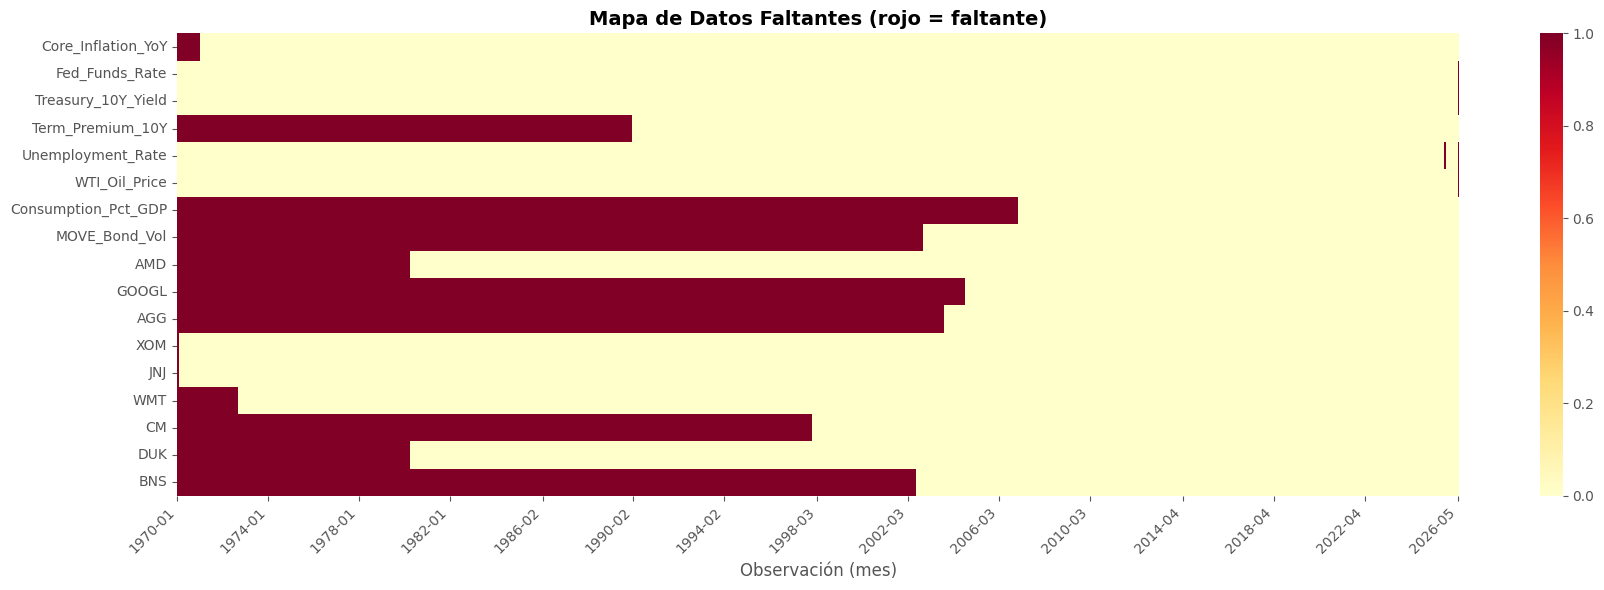

In [31]:
import matplotlib.dates as mdates

print('=' * 70)
print('1.2 CALIDAD DE LOS DATOS')
print('=' * 70)

# Tabla de calidad
quality_rows = []
for col in df_full.columns:
    valid = df_full[col].notna().sum()
    missing = df_full[col].isna().sum()
    pct_miss = (missing / len(df_full)) * 100
    first = df_full[col].first_valid_index()
    last = df_full[col].last_valid_index()
    quality_rows.append({
        'Variable': col,
        'Válidos': valid,
        'Faltantes': missing,
        '% Faltante': round(pct_miss, 1),
        'Tipo': str(df_full[col].dtype),
        'Desde': first.strftime('%Y-%m') if first else 'N/A',
        'Hasta': last.strftime('%Y-%m') if last else 'N/A',
    })

quality_df = pd.DataFrame(quality_rows).set_index('Variable')
print(quality_df.to_string())

# Mapa de datos faltantes
fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(df_full.isnull().T, cbar=True, yticklabels=True, cmap='YlOrRd', ax=ax)
ax.set_title('Mapa de Datos Faltantes (rojo = faltante)', fontsize=14, fontweight='bold')
ax.set_xlabel('Observación (mes)')

# Formatear eje x con año-mes
n_obs = len(df_full)
tick_positions = np.linspace(0, n_obs - 1, min(15, n_obs)).astype(int)
tick_labels = [df_full.index[i].strftime('%Y-%m') for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [32]:
# Estadísticas descriptivas
print('\n--- Estadísticas Descriptivas ---')
display(df_full.describe().round(4).T)


--- Estadísticas Descriptivas ---


,count,mean,std,min,25%,50%,75%,max
Core_Inflation_YoY,665.0,3.8841,2.5495,0.6027,2.1567,2.9680,4.7297,13.6045
Fed_Funds_Rate,676.0,4.8916,3.8343,0.0500,1.6625,4.9250,6.7825,19.1000
Treasury_10Y_Yield,676.0,5.9534,3.0933,0.6200,3.6500,5.8100,7.8150,15.3200
Term_Premium_10Y,437.0,0.8200,0.7414,-0.6471,0.2580,0.7475,1.3336,2.5127
Unemployment_Rate,675.0,6.0489,1.7144,3.4000,4.7500,5.7000,7.2000,14.8000
WTI_Oil_Price,676.0,39.8658,29.0509,3.3100,17.8728,29.6400,60.6275,133.9300
Consumption_Pct_GDP,233.0,67.7892,0.9734,61.8440,67.1417,67.5708,68.6056,70.6406
MOVE_Bond_Vol,283.0,87.0194,30.5872,39.2100,64.0550,80.0000,104.6850,214.0000
AMD,554.0,2.5201,18.1715,-47.7273,-8.6512,0.6633,13.6831,78.0996
GOOGL,261.0,2.3220,8.9263,-18.4773,-3.3547,1.9873,6.9726,47.0988


### **1.3. Tipos de variables**
---

- ¿El conjunto de datos tiene una variable objetivo a estimar?, de ser así, ¿es una variable continúa o categórica?
- Analice la distribución de las etiquetas, identifique si hay desbalanceo de datos.
- ¿El conjunto de datos cuenta con otras variables adicionales?, de ser así, debe analizar cuáles se incorporarán en el modelo y hacer un análisis descriptivo de las mismas.

### ¿El conjunto de datos tiene una variable objetivo a estimar?, de ser así, ¿es una variable continúa o categórica?
Sí, el modelo tiene dos variables objetivo principales: la rentabilidad esperada y la volatilidad de los activos financieros. Ambas son variables continuas.

### Analice la distribución de las etiquetas, identifique si hay desbalanceo de datos.
Al tratarse de regresión de series de tiempo (retornos y volatilidad), el enfoque se centra más en capturar dinámicas temporales y cambios de régimen que en el desbalanceo de clases típico de la clasificación.

### ¿El conjunto de datos cuenta con otras variables adicionales?, de ser así, debe analizar cuáles se incorporarán en el modelo y hacer un análisis descriptivo de las mismas.

Sí, se incorporan variables adicionales como:

Variables Macroeconómicas: Core Inflation, Fed Funds Rate, 10Y Yield, 10Y Term Premium, Unemployment, WTI Oil, Consumption/GDP, MOVE Bond Volatility Index.

Señales de Política Monetaria: El "Hawkish Index" generado mediante análisis de sentimiento (NLP).

Indicadores Técnicos: Derivados de los precios históricos de Yahoo Finance y variables macroeconómicas provenientes de la FED (FRED).

### **1.4. Relación Entre Variables**
---

- Analice si existe alguna relación entre las variables. Puede utilizar medidas de correlación o visualizaciones.
- Identifique si hay redundancia entre las variables para una posterior eliminación o selección.

### Analice si existe alguna relación entre las variables. Puede utilizar medidas de correlación o visualizaciones.
Hay relaciones no lineales y efectos rezagados entre las variables. Por ejemplo, como ya hemos mencionado anteriormente, existe un impacto de la política monetaria y la inflación en el mercado, pero este no es inmediato y puede depender del contexto de otras variables.

### Identifique si hay redundancia entre las variables para una posterior eliminación o selección.
La fase de "Feature Engineering" y la creación del Dataset Unificado incluyen procesos de normalización y selección para identificar patrones persistentes y evitar redundancias que puedan afectar el rendimiento del modelo LSTM.

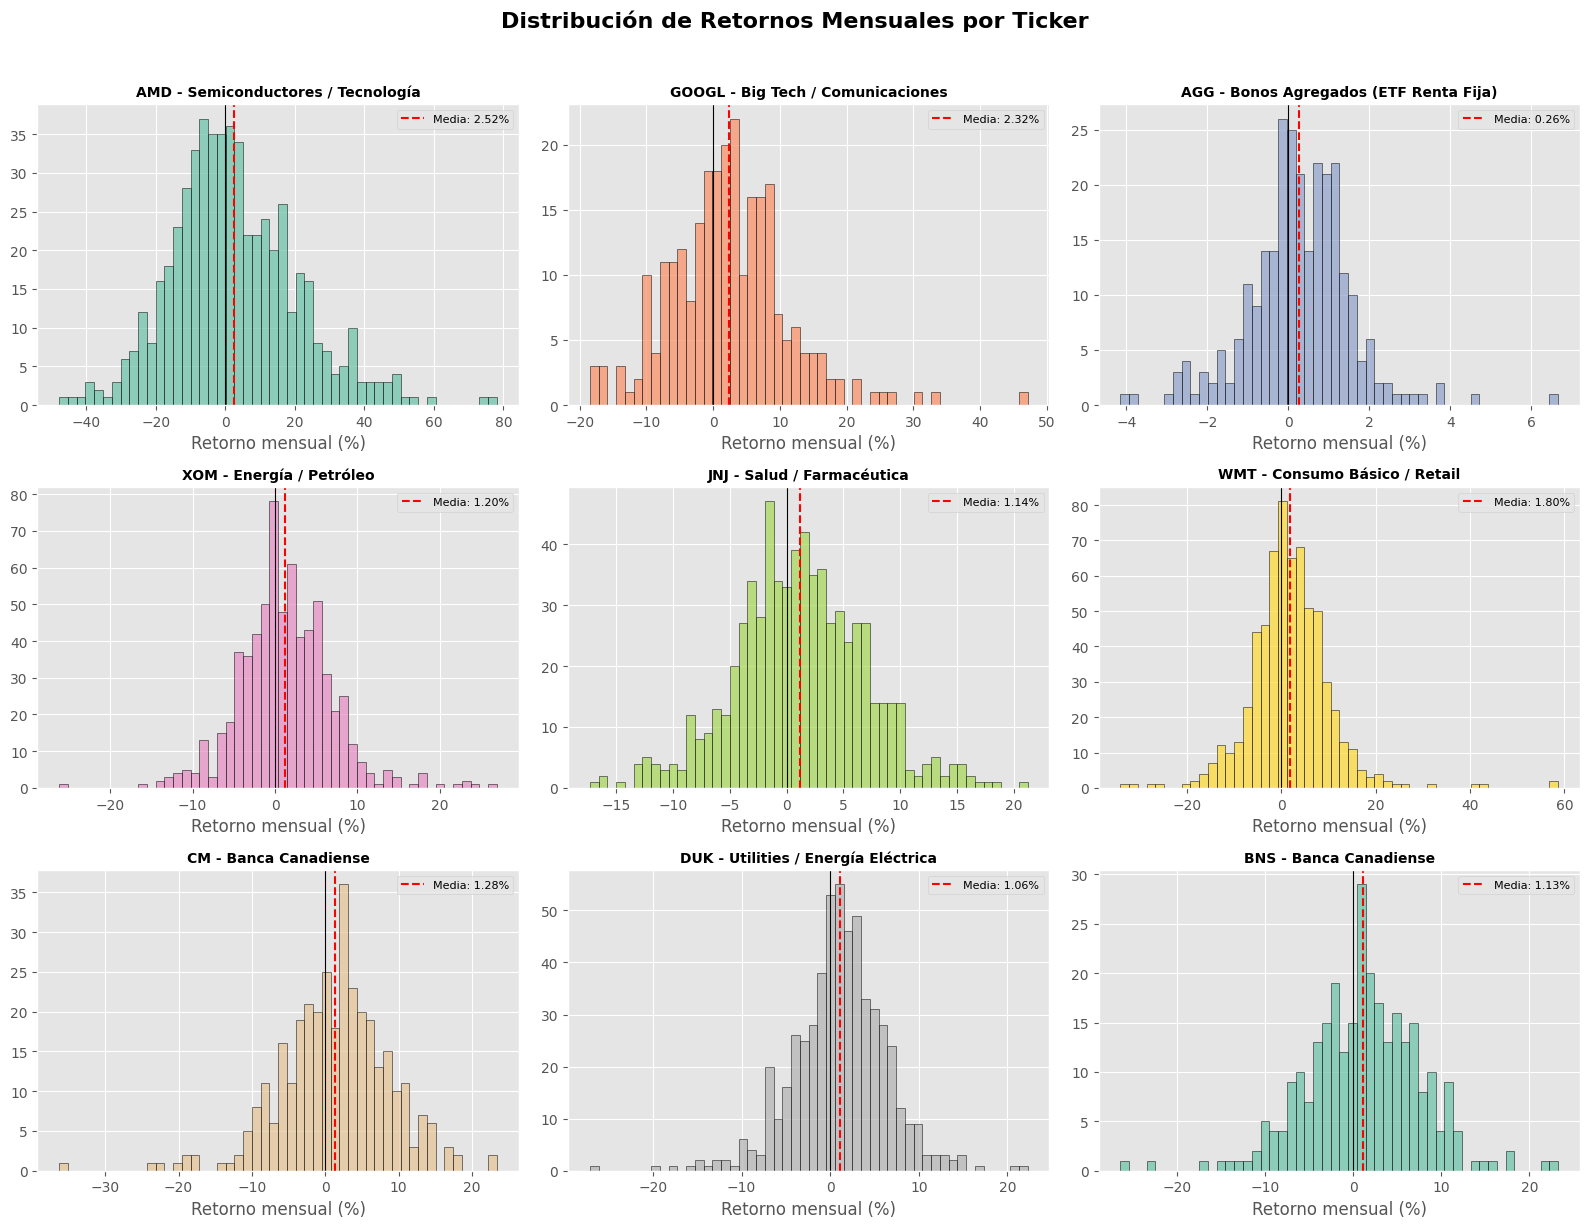

In [33]:
# Histogramas de retornos de tickers
available_tickers = [t for t in tickers if t in df_returns.columns]
n_t = len(available_tickers)
n_cols_t = 3
n_rows_t = (n_t + n_cols_t - 1) // n_cols_t

fig, axes = plt.subplots(n_rows_t, n_cols_t, figsize=(16, 4 * n_rows_t))
axes = axes.flatten()

for i, t in enumerate(available_tickers):
    data = df_returns[t].dropna()
    axes[i].hist(data, bins=50, edgecolor='black', alpha=0.7, color=sns.color_palette('Set2')[i % 8])
    axes[i].set_title(f'{t} - {ticker_info[t]}', fontsize=10, fontweight='bold')
    axes[i].axvline(data.mean(), color='red', ls='--', label=f'Media: {data.mean():.2f}%')
    axes[i].axvline(0, color='black', ls='-', lw=0.8)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Retorno mensual (%)')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Retornos Mensuales por Ticker', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

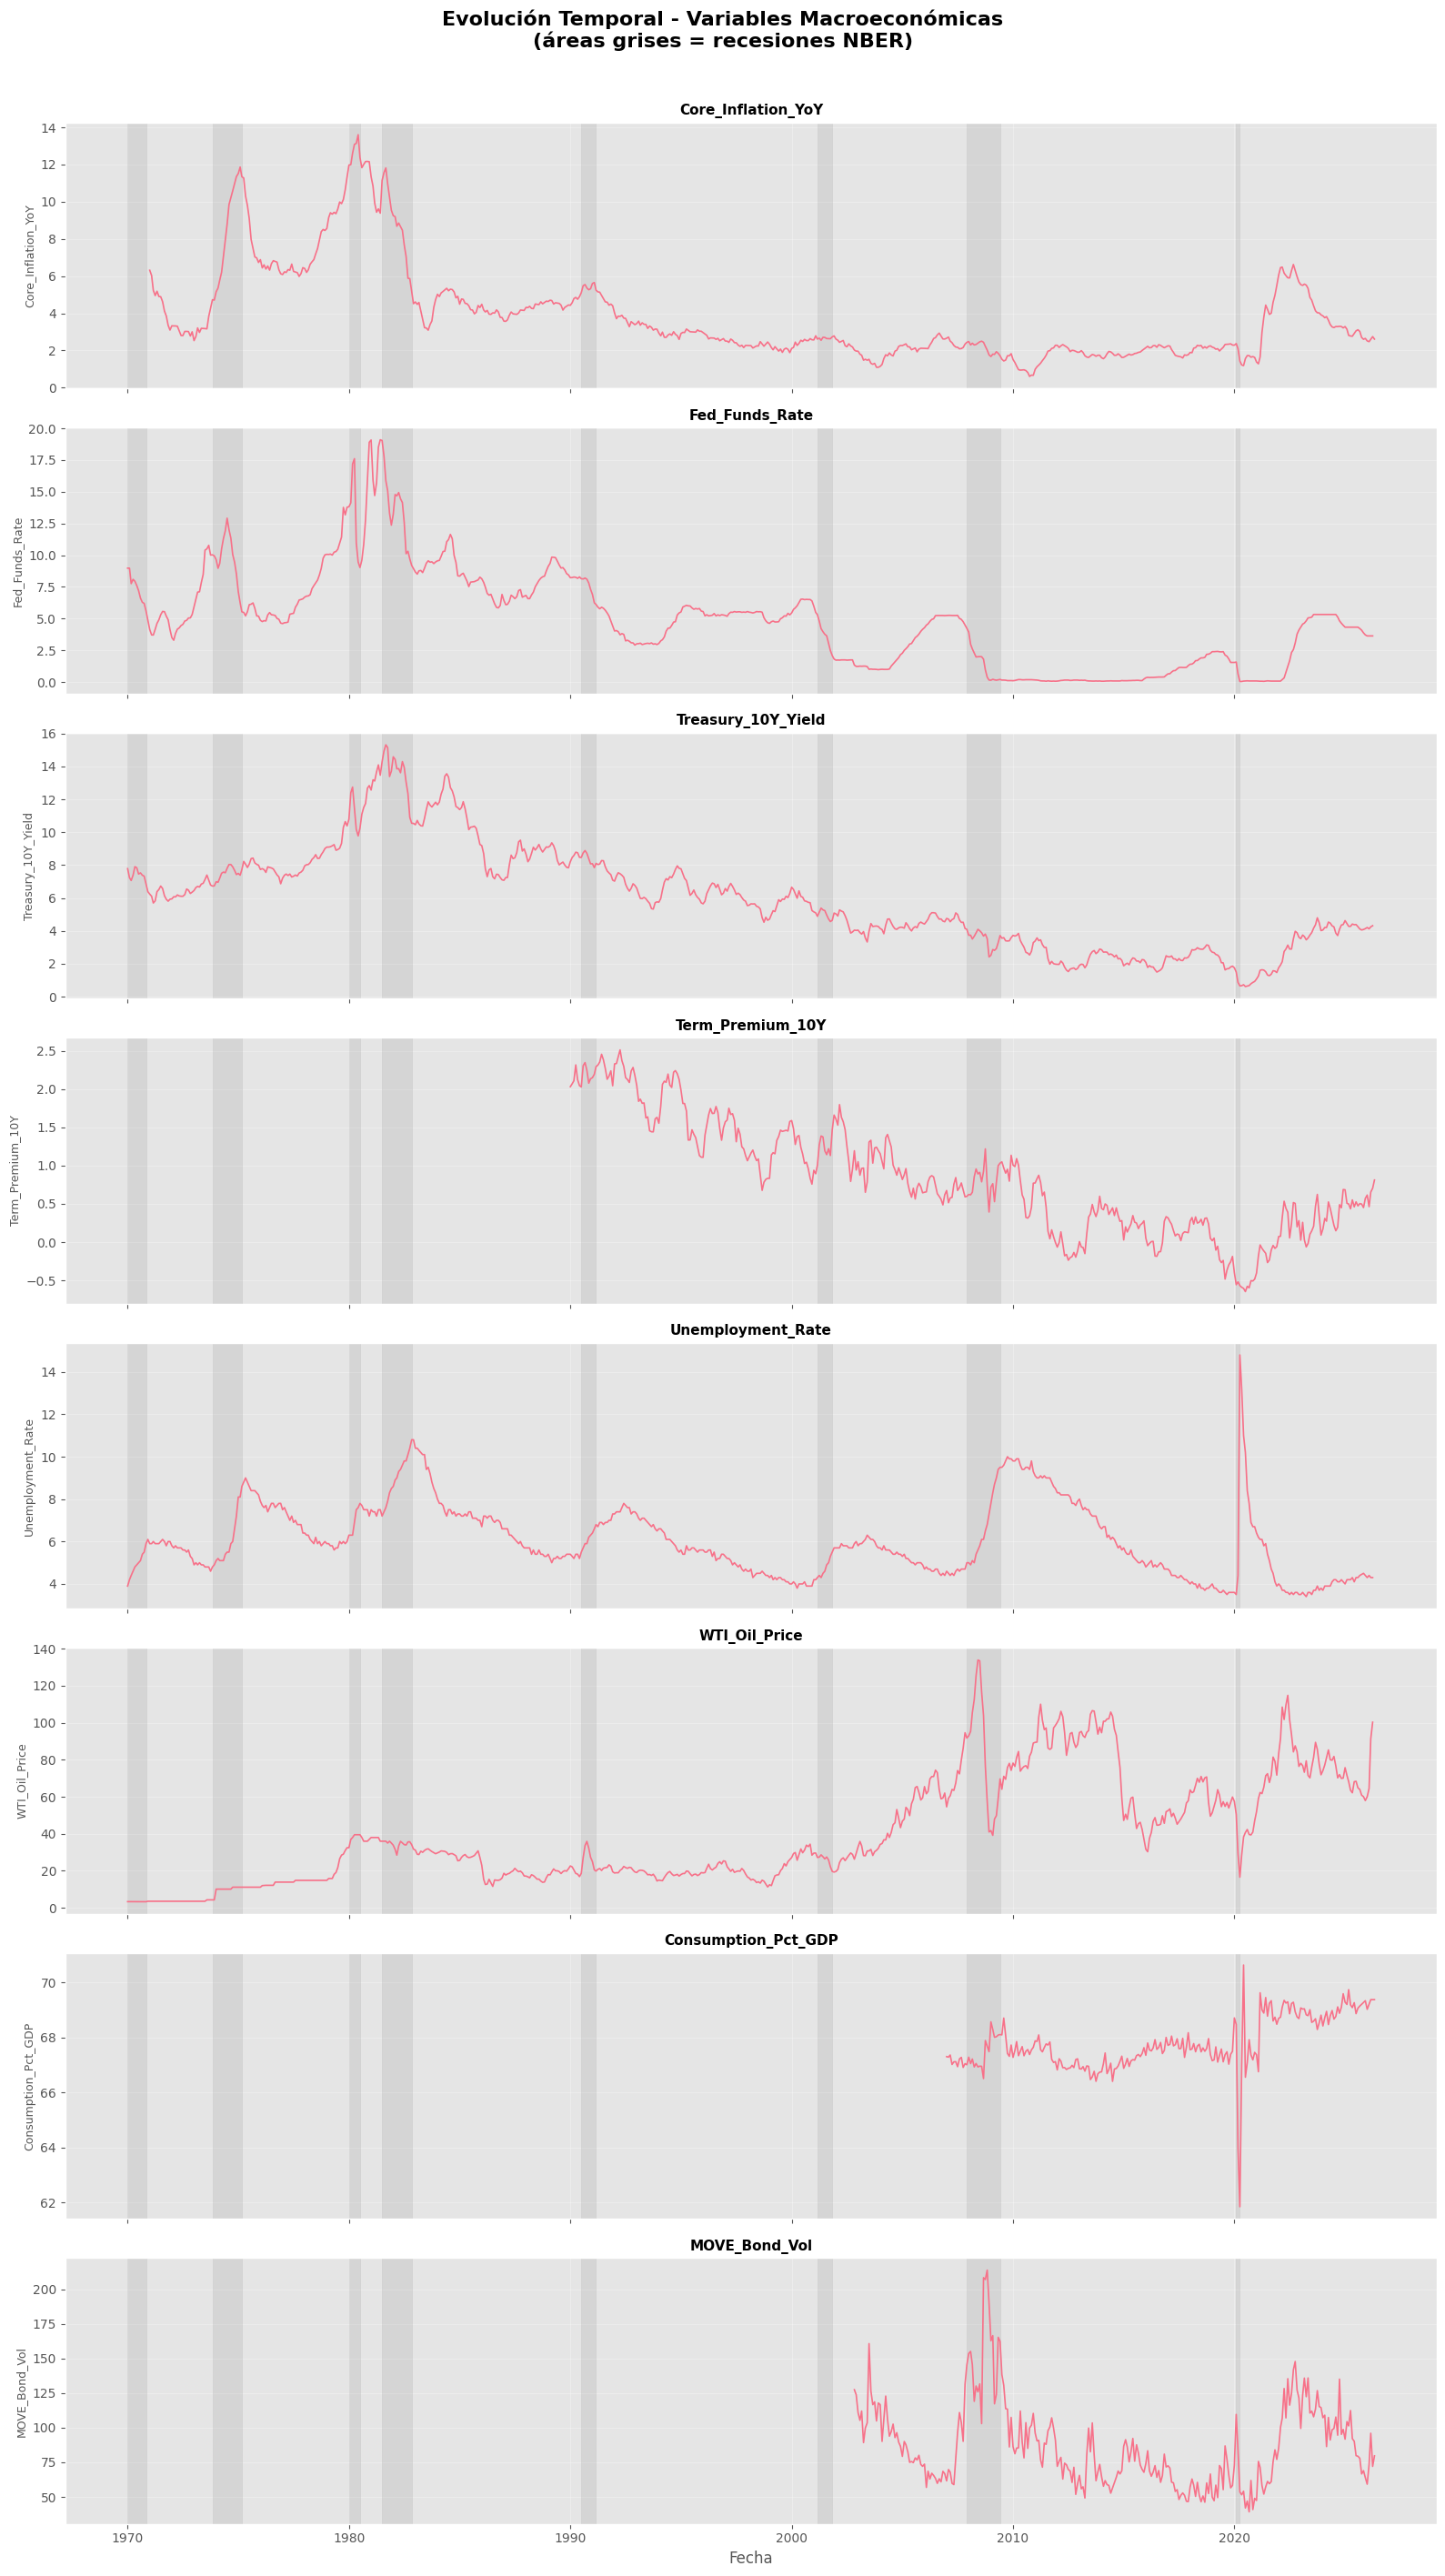

In [34]:
# Series temporales de variables macro con recesiones NBER
recessions = [
    ('1970-01', '1970-11'), ('1973-11', '1975-03'), ('1980-01', '1980-07'),
    ('1981-07', '1982-11'), ('1990-07', '1991-03'), ('2001-03', '2001-11'),
    ('2007-12', '2009-06'), ('2020-02', '2020-04')
]

fig, axes = plt.subplots(len(macro_vars), 1, figsize=(16, 3.5 * len(macro_vars)), sharex=True)

for i, var in enumerate(macro_vars):
    data = df_macro_final[var].dropna()
    axes[i].plot(data.index, data.values, lw=1.2)
    axes[i].set_ylabel(var, fontsize=9)
    axes[i].set_title(var, fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    for s, e in recessions:
        axes[i].axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.15, color='gray')

axes[-1].set_xlabel('Fecha')
plt.suptitle('Evolución Temporal - Variables Macroeconómicas\n(áreas grises = recesiones NBER)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

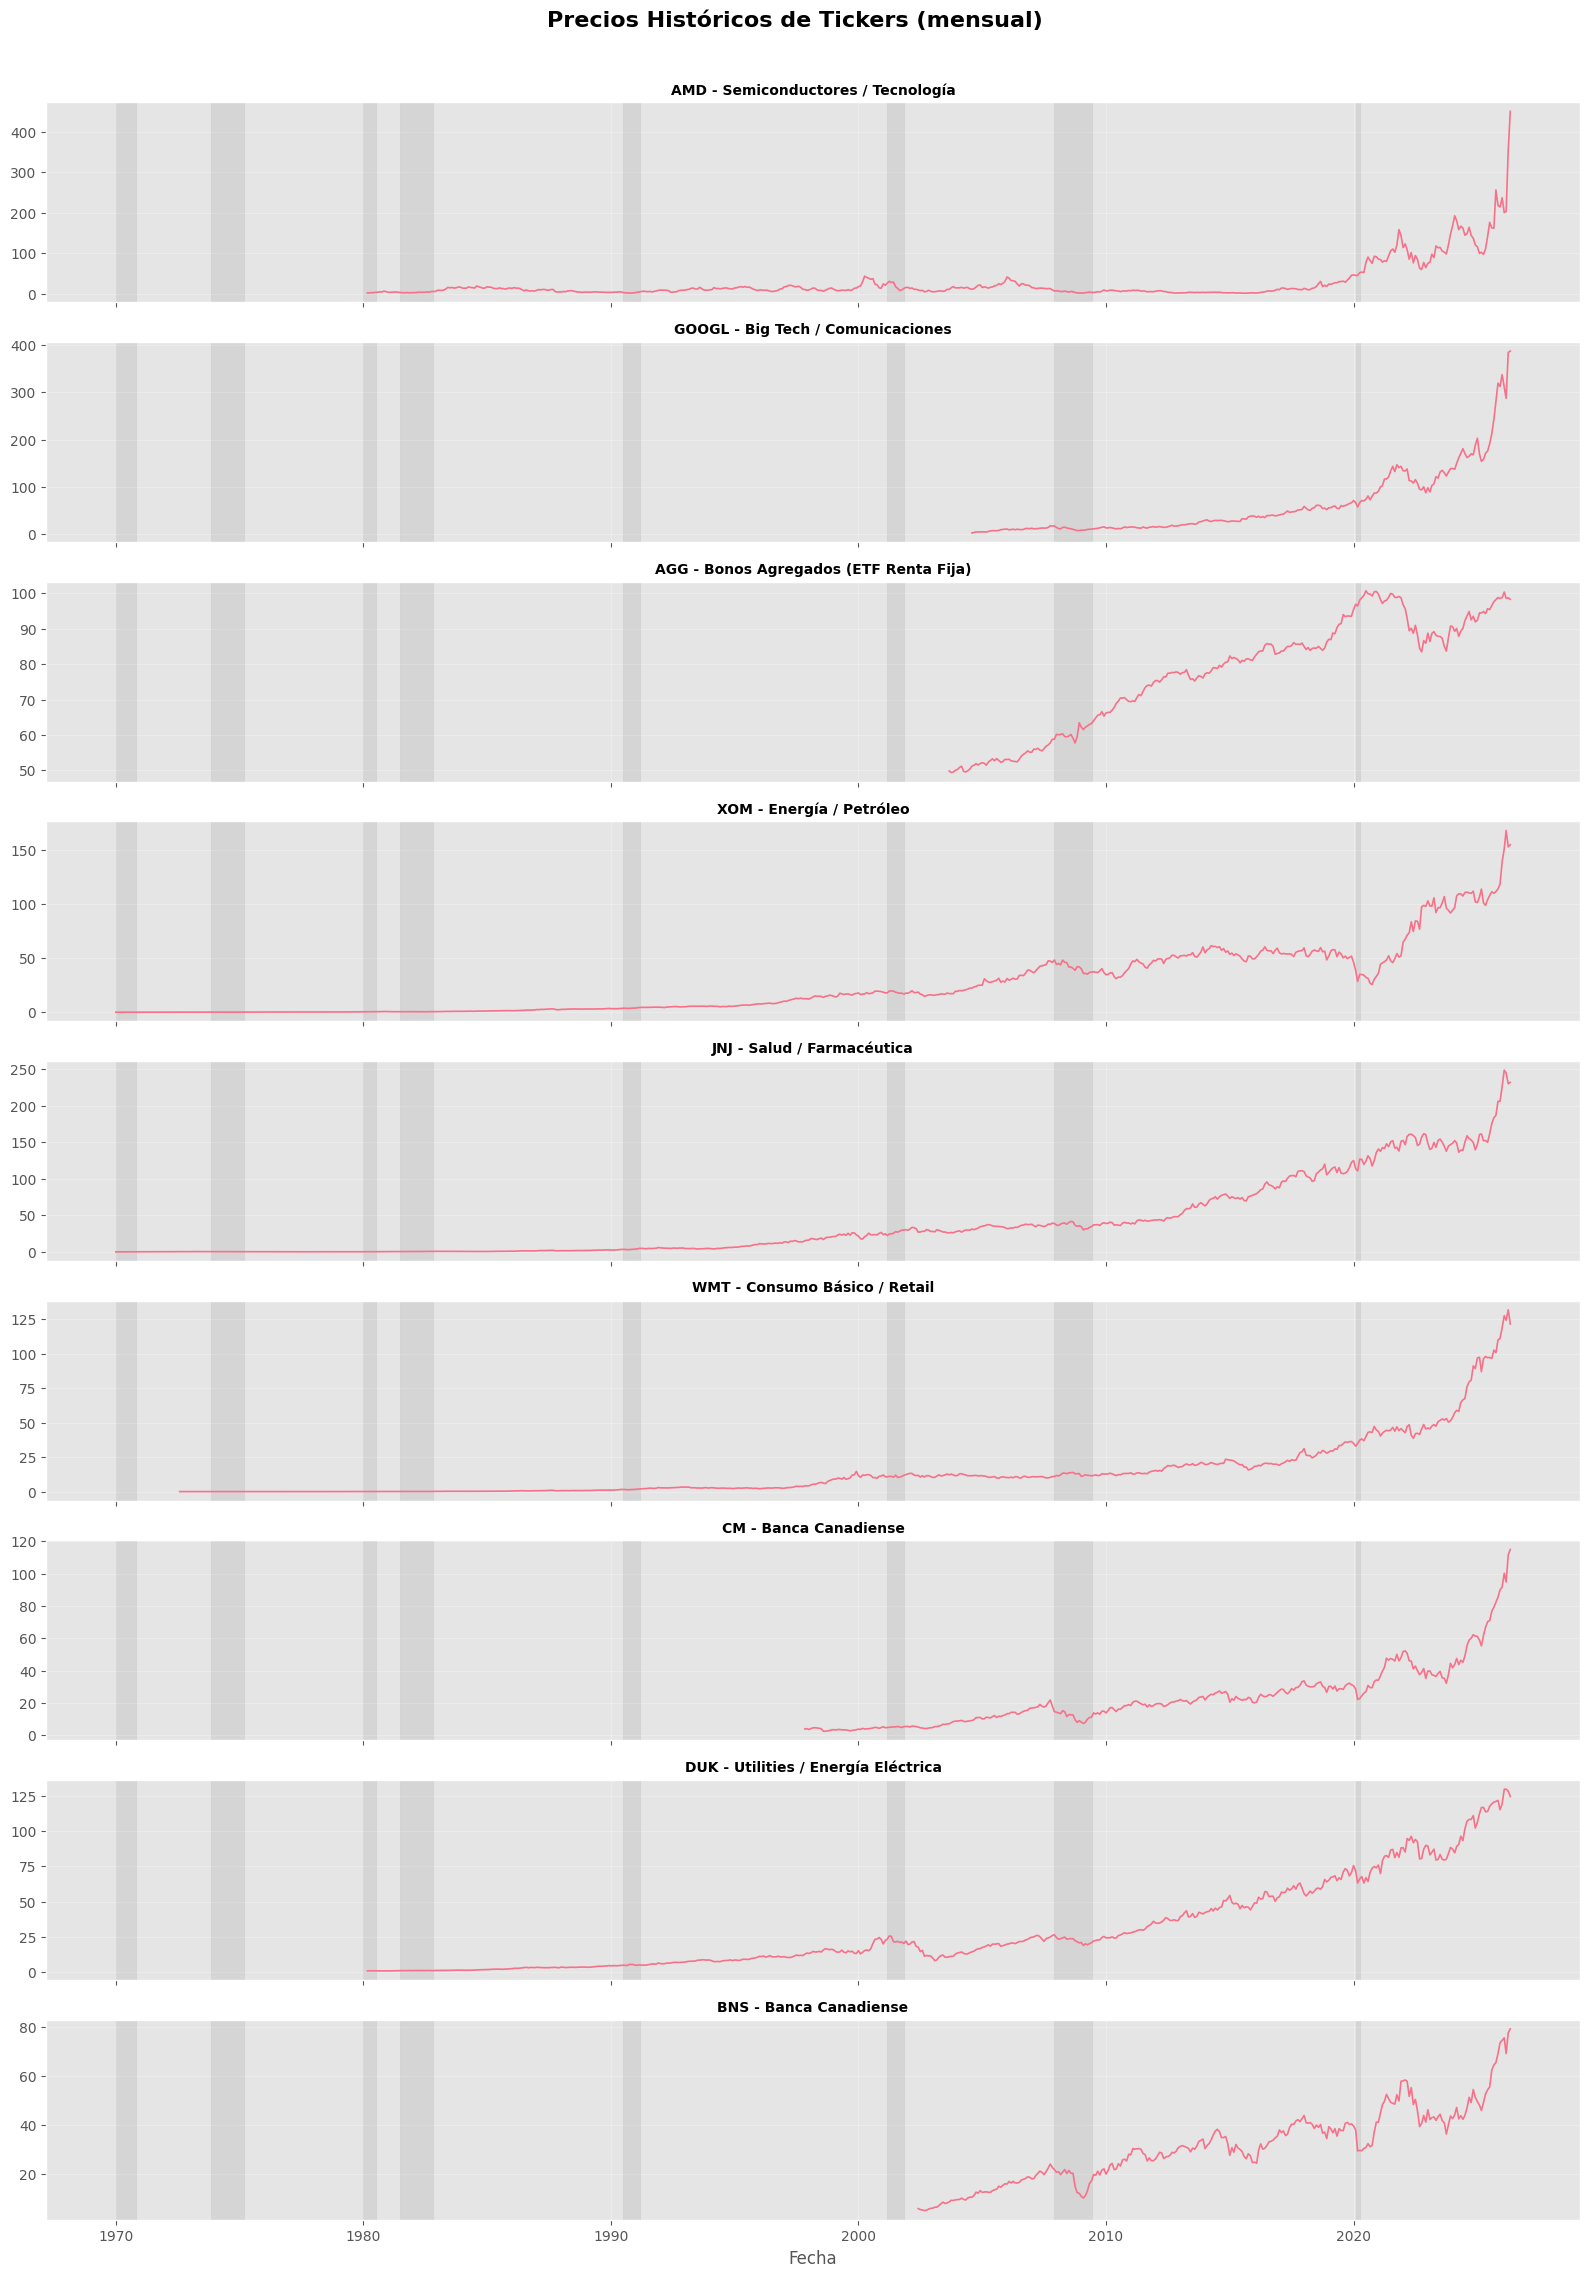

In [35]:
# Series temporales de precios de tickers
fig, axes = plt.subplots(len(available_tickers), 1,
                         figsize=(16, 2.5 * len(available_tickers)), sharex=True)
if len(available_tickers) == 1:
    axes = [axes]

for i, t in enumerate(available_tickers):
    data = df_prices[t].dropna()
    axes[i].plot(data.index, data.values, lw=1.2)
    axes[i].set_title(f'{t} - {ticker_info[t]}', fontsize=10, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    for s, e in recessions:
        axes[i].axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.15, color='gray')

axes[-1].set_xlabel('Fecha')
plt.suptitle('Precios Históricos de Tickers (mensual)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 1.4 Relación Entre Variables

### 1.4.1 Correlación entre variables macroeconómicas

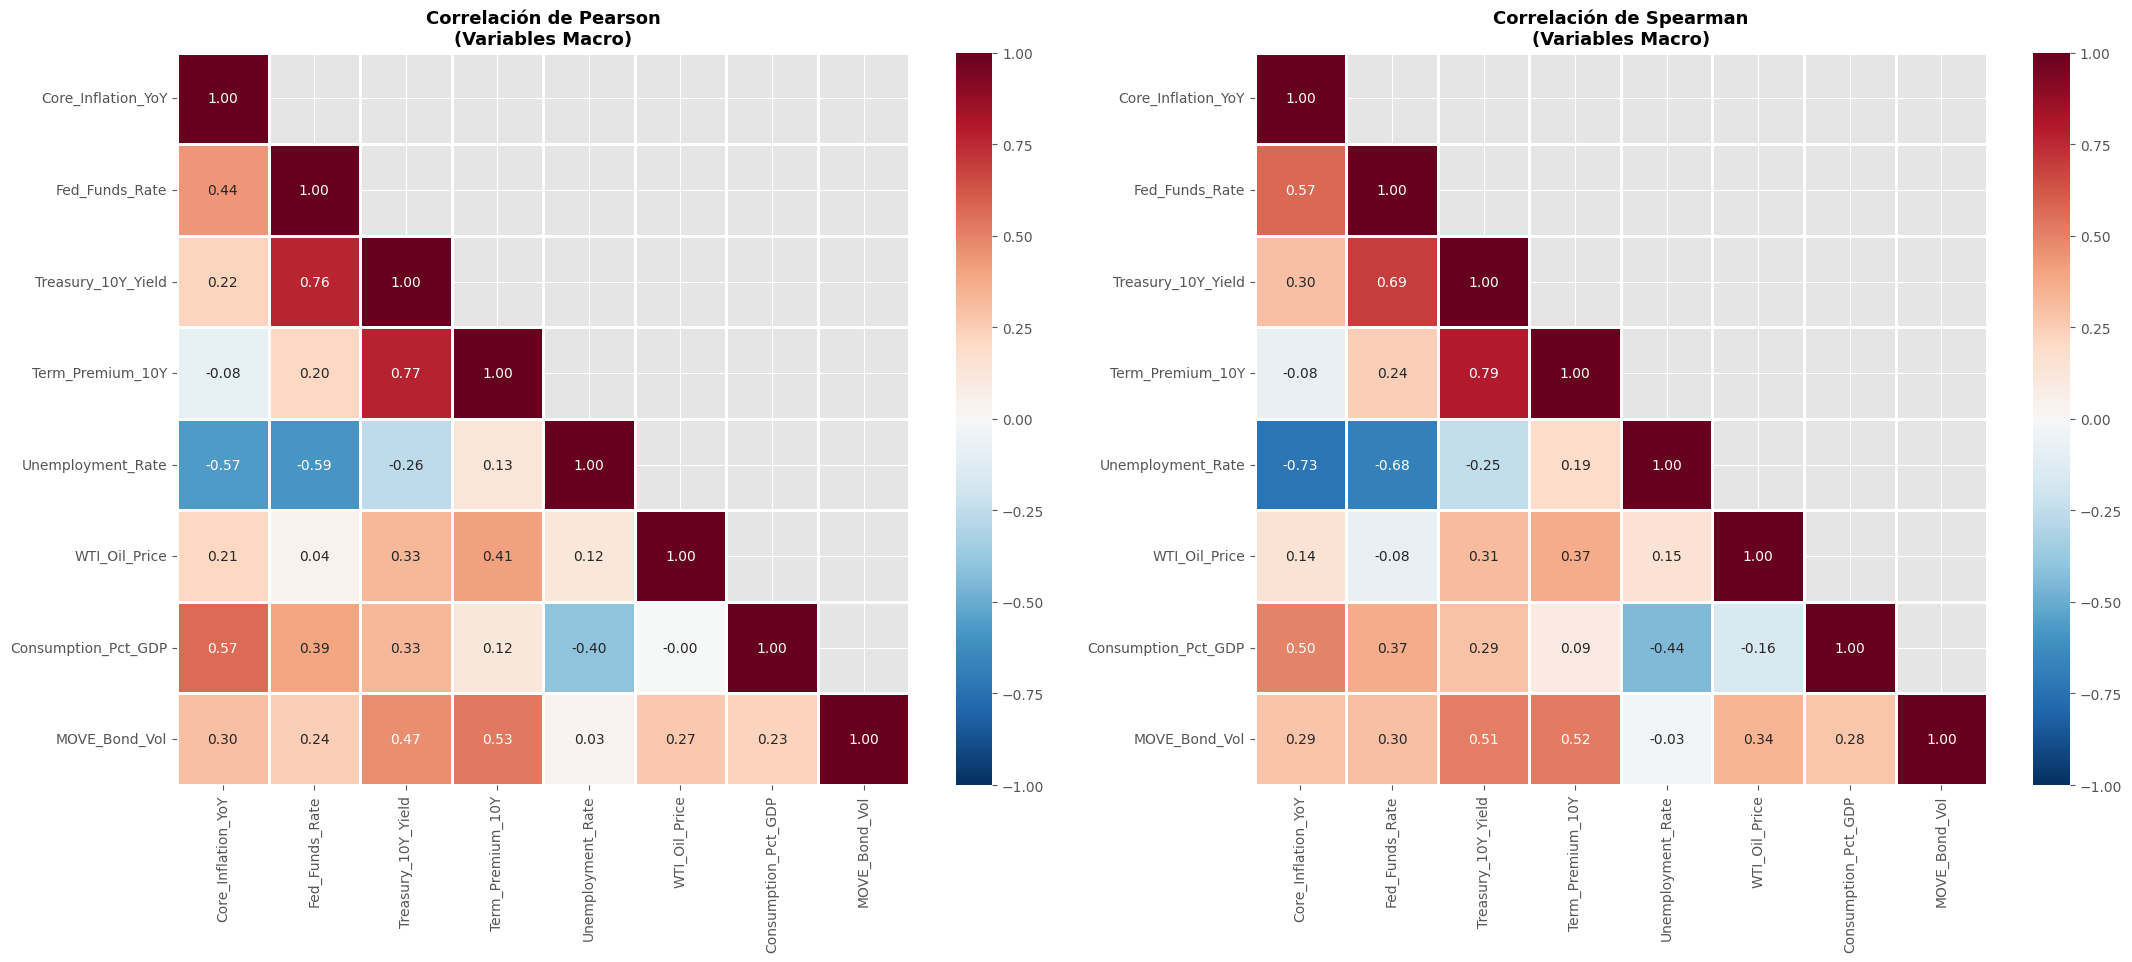


Pares con correlación alta (|r| > 0.6):
  Fed_Funds_Rate ↔ Treasury_10Y_Yield: r=0.762  → Significativa
  Treasury_10Y_Yield ↔ Term_Premium_10Y: r=0.770  → Significativa


In [36]:
# Correlación entre variables macro
df_macro_clean = df_macro_final.dropna()

corr_macro = df_macro_clean.corr(method='pearson')

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Pearson
mask = np.triu(np.ones_like(corr_macro, dtype=bool), k=1)
sns.heatmap(corr_macro, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=1, vmin=-1, vmax=1, ax=axes[0],
            annot_kws={'size': 10})
axes[0].set_title('Correlación de Pearson\n(Variables Macro)', fontsize=13, fontweight='bold')

# Spearman
corr_spearman = df_macro_clean.corr(method='spearman')
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=1, vmin=-1, vmax=1, ax=axes[1],
            annot_kws={'size': 10})
axes[1].set_title('Correlación de Spearman\n(Variables Macro)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Pares con alta correlación
print('\nPares con correlación alta (|r| > 0.6):')
high_corr_macro = []
for i in range(len(corr_macro.columns)):
    for j in range(i + 1, len(corr_macro.columns)):
        r = corr_macro.iloc[i, j]
        if abs(r) > 0.6:
            high_corr_macro.append((corr_macro.columns[i], corr_macro.columns[j], r))
            tag = '⚠️  REDUNDANCIA' if abs(r) > 0.8 else 'Significativa'
            print(f'  {corr_macro.columns[i]} ↔ {corr_macro.columns[j]}: r={r:.3f}  → {tag}')

### 1.4.2 Correlación entre retornos de tickers

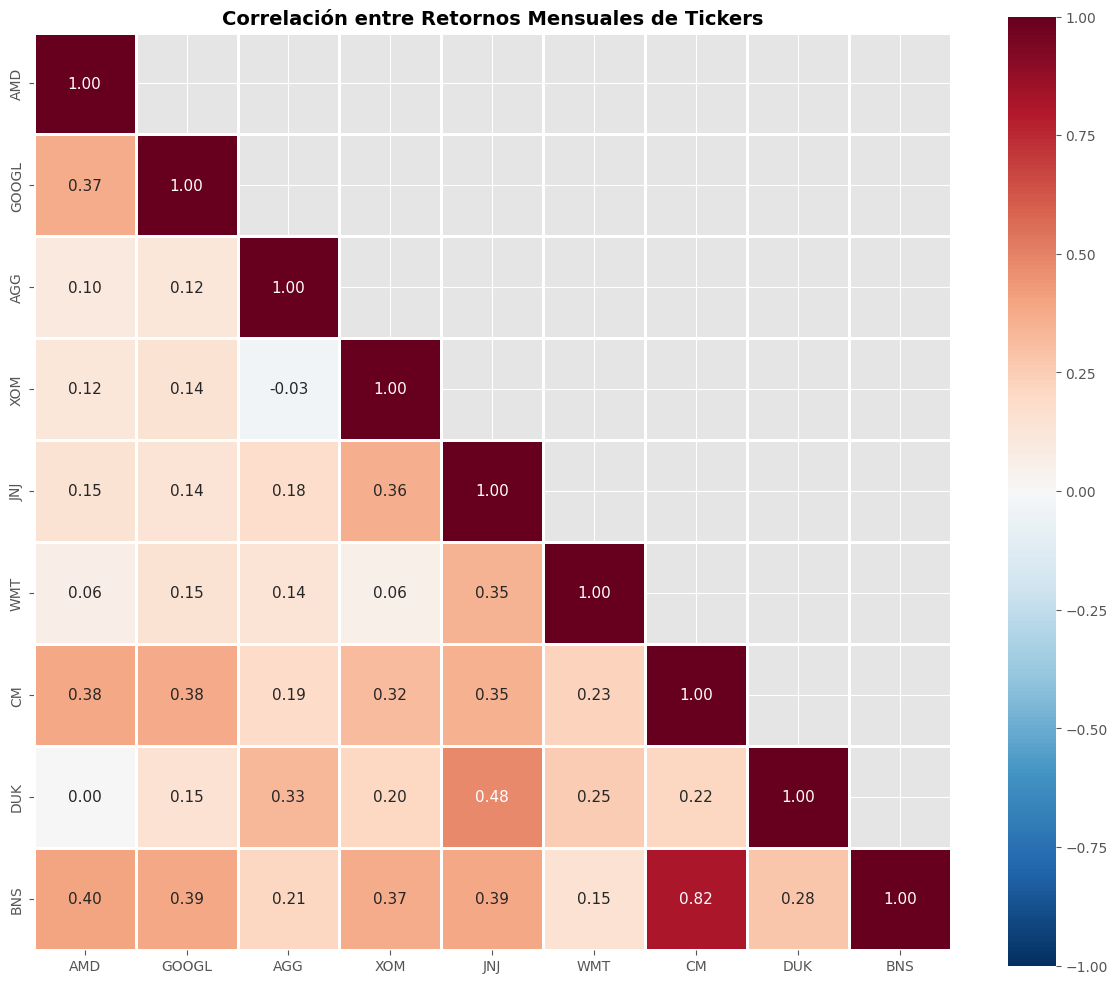

In [37]:
# Correlación entre retornos de tickers
df_ret_clean = df_returns[available_tickers].dropna()

if len(df_ret_clean) > 10:
    corr_tickers = df_ret_clean.corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_tickers, dtype=bool), k=1)
    sns.heatmap(corr_tickers, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                mask=mask, square=True, linewidths=1, vmin=-1, vmax=1, ax=ax,
                annot_kws={'size': 11})
    ax.set_title('Correlación entre Retornos Mensuales de Tickers', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Datos insuficientes para correlación entre tickers')

### 1.4.3 Correlación entre Variables Macroeconómicas y Retornos de Tickers

Esta es la **relación central** del proyecto: ¿cómo se relacionan las condiciones macro con los retornos sectoriales?

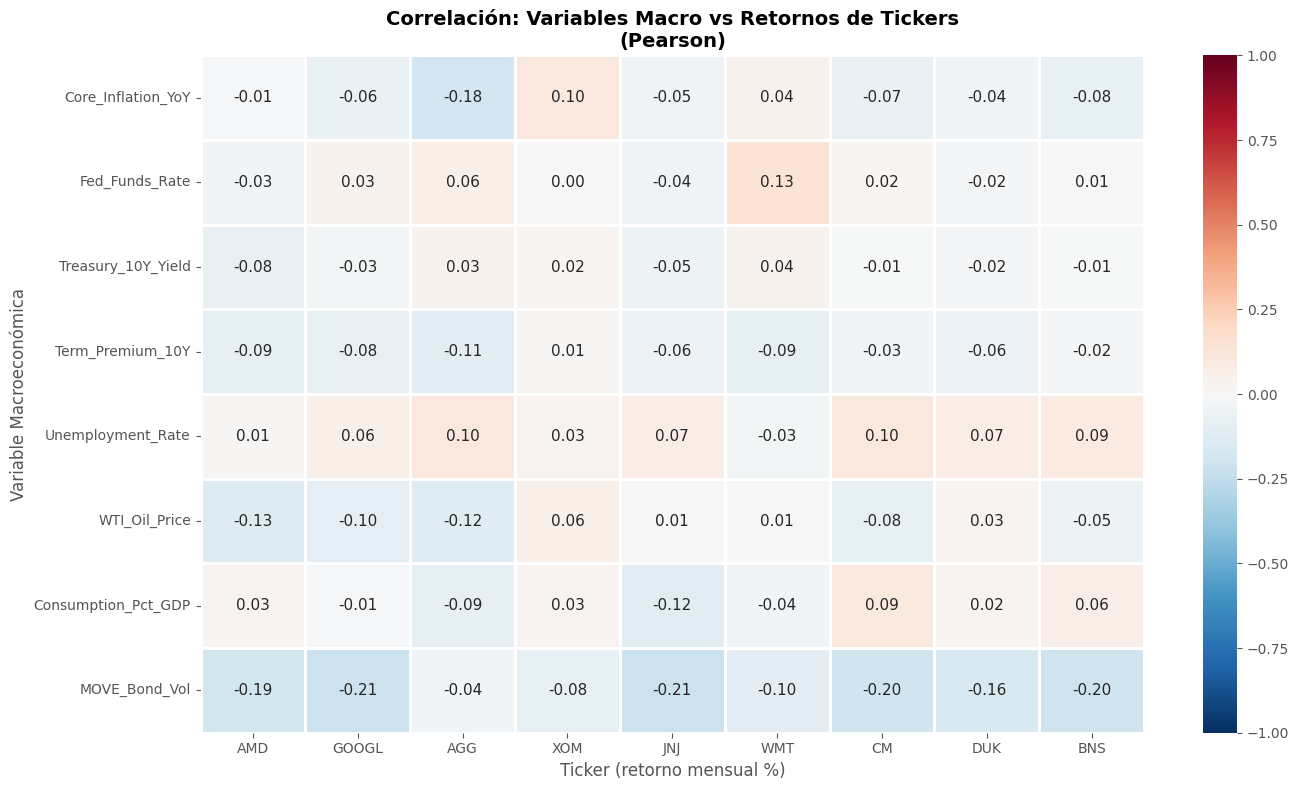


Relaciones más fuertes (Macro → Ticker):
  Core_Inflation_YoY → AGG: r=-0.181 ↑↓
  MOVE_Bond_Vol → AMD: r=-0.192 ↑↓
  MOVE_Bond_Vol → GOOGL: r=-0.212 ↑↓
  MOVE_Bond_Vol → JNJ: r=-0.214 ↑↓
  MOVE_Bond_Vol → CM: r=-0.199 ↑↓
  MOVE_Bond_Vol → DUK: r=-0.163 ↑↓
  MOVE_Bond_Vol → BNS: r=-0.205 ↑↓


In [38]:
# Correlación Macro vs Retornos de Tickers
df_combined = df_full.dropna()
macro_in_combined = [v for v in macro_vars if v in df_combined.columns]
tickers_in_combined = [t for t in available_tickers if t in df_combined.columns]

if len(df_combined) > 10 and len(macro_in_combined) > 0 and len(tickers_in_combined) > 0:
    corr_cross = df_combined[macro_in_combined + tickers_in_combined].corr()
    # Extraer solo macro vs tickers
    corr_cross_sub = corr_cross.loc[macro_in_combined, tickers_in_combined]

    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(corr_cross_sub, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                linewidths=1, vmin=-1, vmax=1, ax=ax, annot_kws={'size': 11})
    ax.set_title('Correlación: Variables Macro vs Retornos de Tickers\n(Pearson)',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Variable Macroeconómica')
    ax.set_xlabel('Ticker (retorno mensual %)')
    plt.tight_layout()
    plt.show()

    # Resumen de relaciones más fuertes
    print('\nRelaciones más fuertes (Macro → Ticker):')
    for macro_v in macro_in_combined:
        for ticker_v in tickers_in_combined:
            r = corr_cross_sub.loc[macro_v, ticker_v]
            if abs(r) > 0.15:
                direction = '↑↑' if r > 0 else '↑↓'
                print(f'  {macro_v} → {ticker_v}: r={r:.3f} {direction}')
else:
    print(f'Datos combinados insuficientes: {len(df_combined)} obs con datos completos')
    print('Intentando con pares individuales...')
    # Calcular correlaciones por pares sin exigir completitud total
    results = []
    for mv in macro_vars:
        for tv in available_tickers:
            temp = df_full[[mv, tv]].dropna()
            if len(temp) > 30:
                r = temp[mv].corr(temp[tv])
                results.append({'Macro': mv, 'Ticker': tv, 'r': round(r, 3), 'N': len(temp)})
    if results:
        corr_pairs_df = pd.DataFrame(results)
        corr_pivot = corr_pairs_df.pivot(index='Macro', columns='Ticker', values='r')

        fig, ax = plt.subplots(figsize=(14, 8))
        sns.heatmap(corr_pivot, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                    linewidths=1, vmin=-1, vmax=1, ax=ax, annot_kws={'size': 11})
        ax.set_title('Correlación: Variables Macro vs Retornos de Tickers\n(Pearson, pares individuales)',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print('\nRelaciones más fuertes:')
        strong = corr_pairs_df[corr_pairs_df['r'].abs() > 0.15].sort_values('r', key=abs, ascending=False)
        print(strong.to_string(index=False))

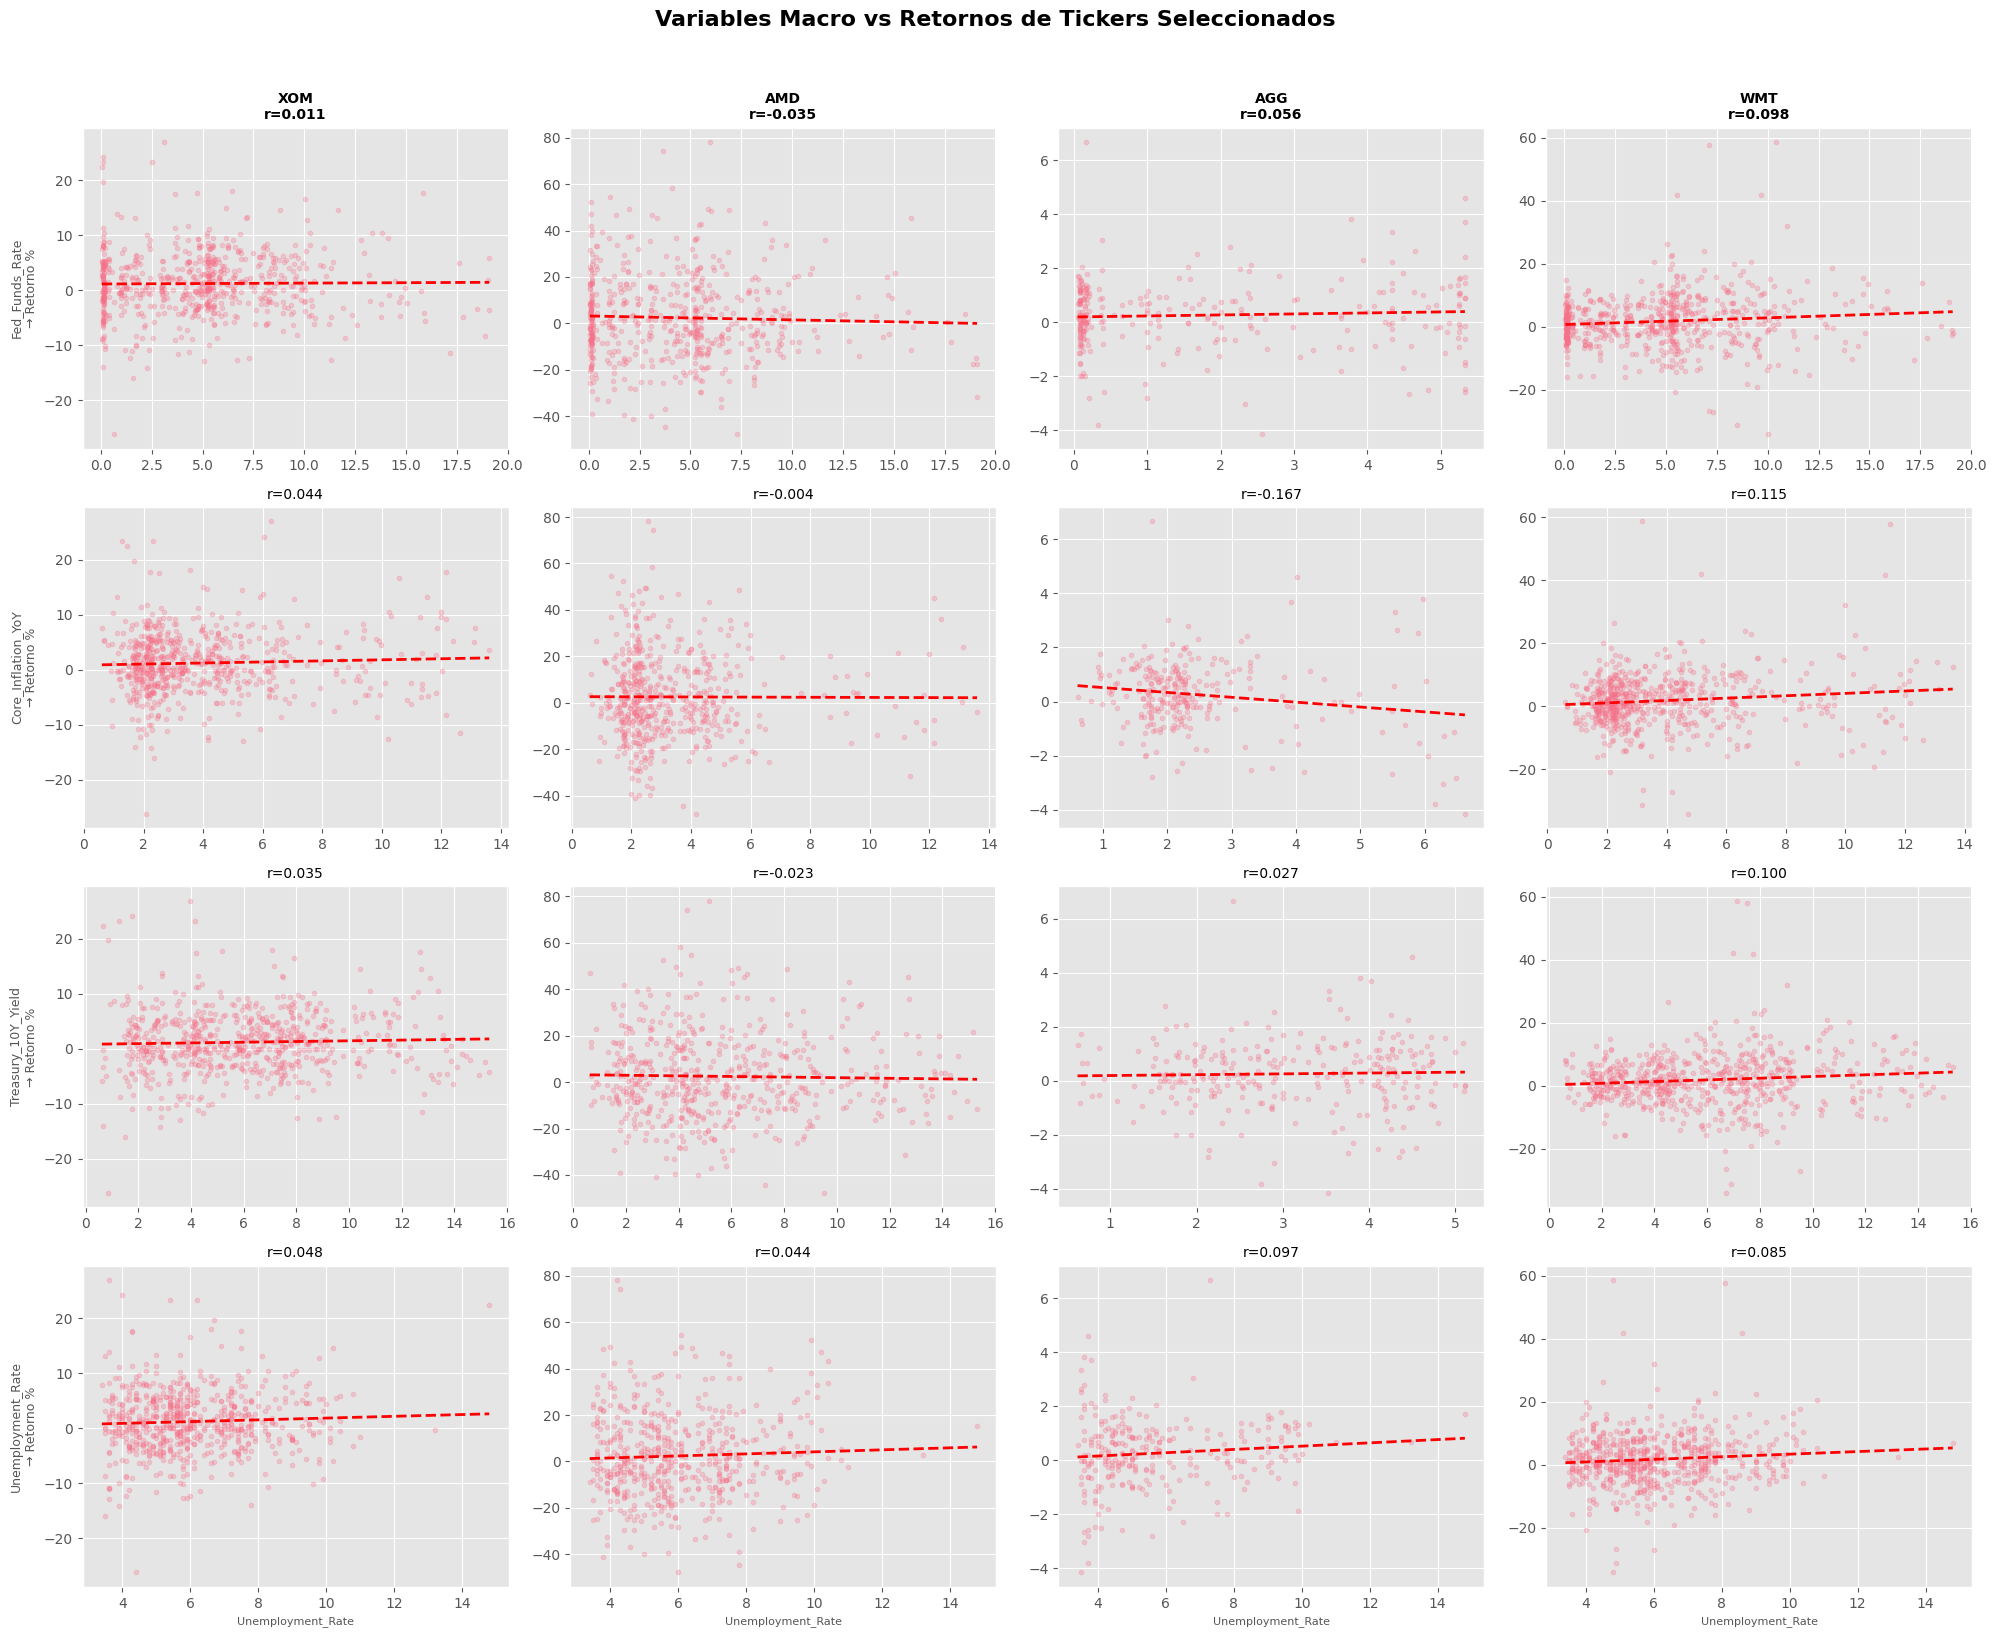

In [39]:
# Scatter plots: Variables macro clave vs retornos de tickers seleccionados
key_macro = ['Fed_Funds_Rate', 'Core_Inflation_YoY', 'Treasury_10Y_Yield', 'Unemployment_Rate']
key_macro = [v for v in key_macro if v in df_full.columns]
sample_tickers = [t for t in ['XOM', 'AMD', 'AGG', 'WMT'] if t in df_full.columns]

if key_macro and sample_tickers:
    fig, axes = plt.subplots(len(key_macro), len(sample_tickers),
                             figsize=(5 * len(sample_tickers), 4 * len(key_macro)))
    if len(key_macro) == 1:
        axes = axes.reshape(1, -1)
    if len(sample_tickers) == 1:
        axes = axes.reshape(-1, 1)

    for i, mv in enumerate(key_macro):
        for j, tv in enumerate(sample_tickers):
            temp = df_full[[mv, tv]].dropna()
            if len(temp) > 10:
                axes[i, j].scatter(temp[mv], temp[tv], alpha=0.3, s=12)
                z = np.polyfit(temp[mv], temp[tv], 1)
                p = np.poly1d(z)
                x_line = np.linspace(temp[mv].min(), temp[mv].max(), 100)
                axes[i, j].plot(x_line, p(x_line), 'r--', lw=2)
                r = temp[mv].corr(temp[tv])
                axes[i, j].set_title(f'r={r:.3f}', fontsize=10)
            axes[i, j].set_xlabel(mv if i == len(key_macro) - 1 else '', fontsize=8)
            axes[i, j].set_ylabel(tv if j == 0 else '', fontsize=8)
            if i == 0:
                axes[i, j].set_title(f'{tv}\nr={r:.3f}' if len(temp) > 10 else tv,
                                     fontsize=10, fontweight='bold')

    # Row labels
    for i, mv in enumerate(key_macro):
        axes[i, 0].set_ylabel(f'{mv}\n→ Retorno %', fontsize=9)

    plt.suptitle('Variables Macro vs Retornos de Tickers Seleccionados',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

### 1.4.4 Correlaciones Móviles (Rolling) - Macro vs Sectores

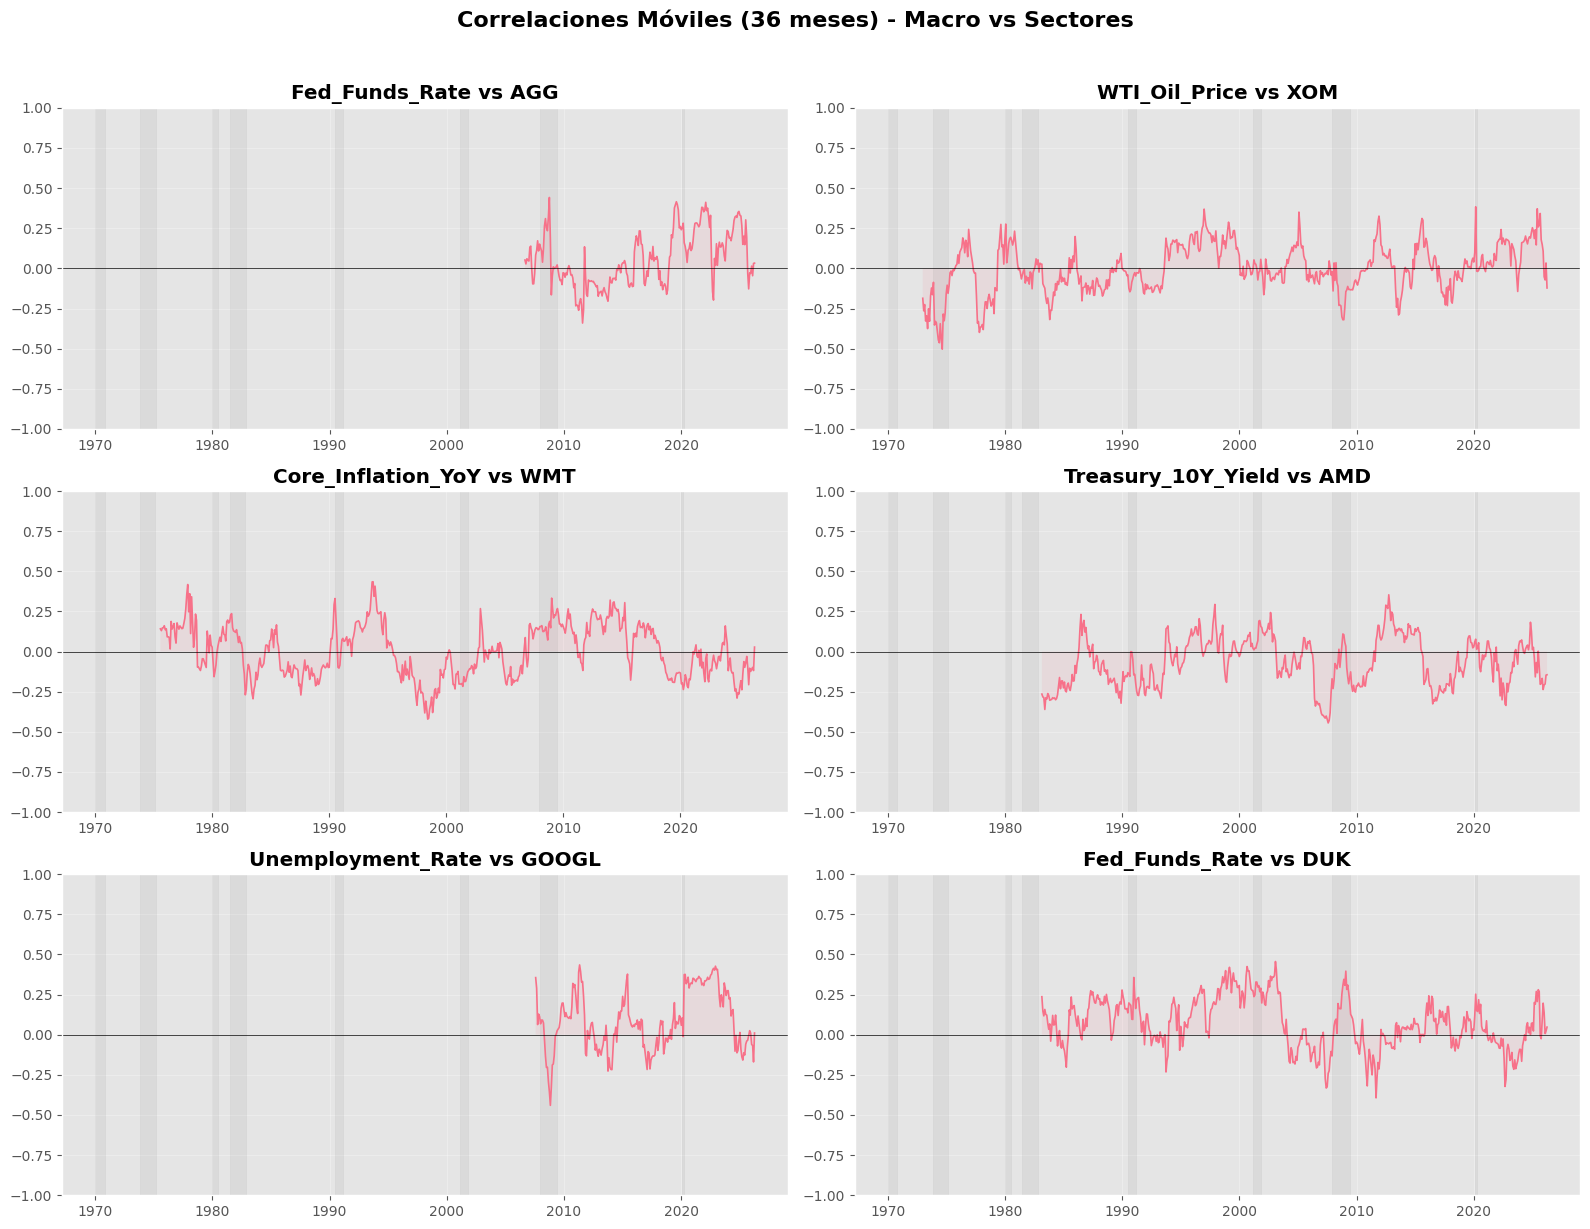

In [40]:
# Correlaciones móviles: cómo cambia la relación en el tiempo
window = 36  # ventana de 3 años

focus_pairs = [
    ('Fed_Funds_Rate', 'AGG'),
    ('WTI_Oil_Price', 'XOM'),
    ('Core_Inflation_YoY', 'WMT'),
    ('Treasury_10Y_Yield', 'AMD'),
    ('Unemployment_Rate', 'GOOGL'),
    ('Fed_Funds_Rate', 'DUK'),
]
focus_pairs = [(m, t) for m, t in focus_pairs if m in df_full.columns and t in df_full.columns]

if focus_pairs:
    n_p = len(focus_pairs)
    n_c = 2
    n_r = (n_p + n_c - 1) // n_c

    fig, axes = plt.subplots(n_r, n_c, figsize=(16, 4 * n_r))
    axes = axes.flatten()

    for idx, (mv, tv) in enumerate(focus_pairs):
        temp = df_full[[mv, tv]].dropna()
        if len(temp) > window:
            roll_corr = temp[mv].rolling(window=window).corr(temp[tv])
            axes[idx].plot(roll_corr.index, roll_corr.values, lw=1.2)
            axes[idx].axhline(0, color='black', lw=0.5)
            axes[idx].fill_between(roll_corr.index, roll_corr.values, 0, alpha=0.1)
            axes[idx].set_ylim(-1, 1)
            axes[idx].set_title(f'{mv} vs {tv}', fontweight='bold')
            axes[idx].grid(True, alpha=0.3)
            for s, e in recessions:
                axes[idx].axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.1, color='gray')

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'Correlaciones Móviles ({window} meses) - Macro vs Sectores',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No hay pares suficientes para correlaciones móviles')

### 1.4.5 Relaciones Clave entre Variables Macro

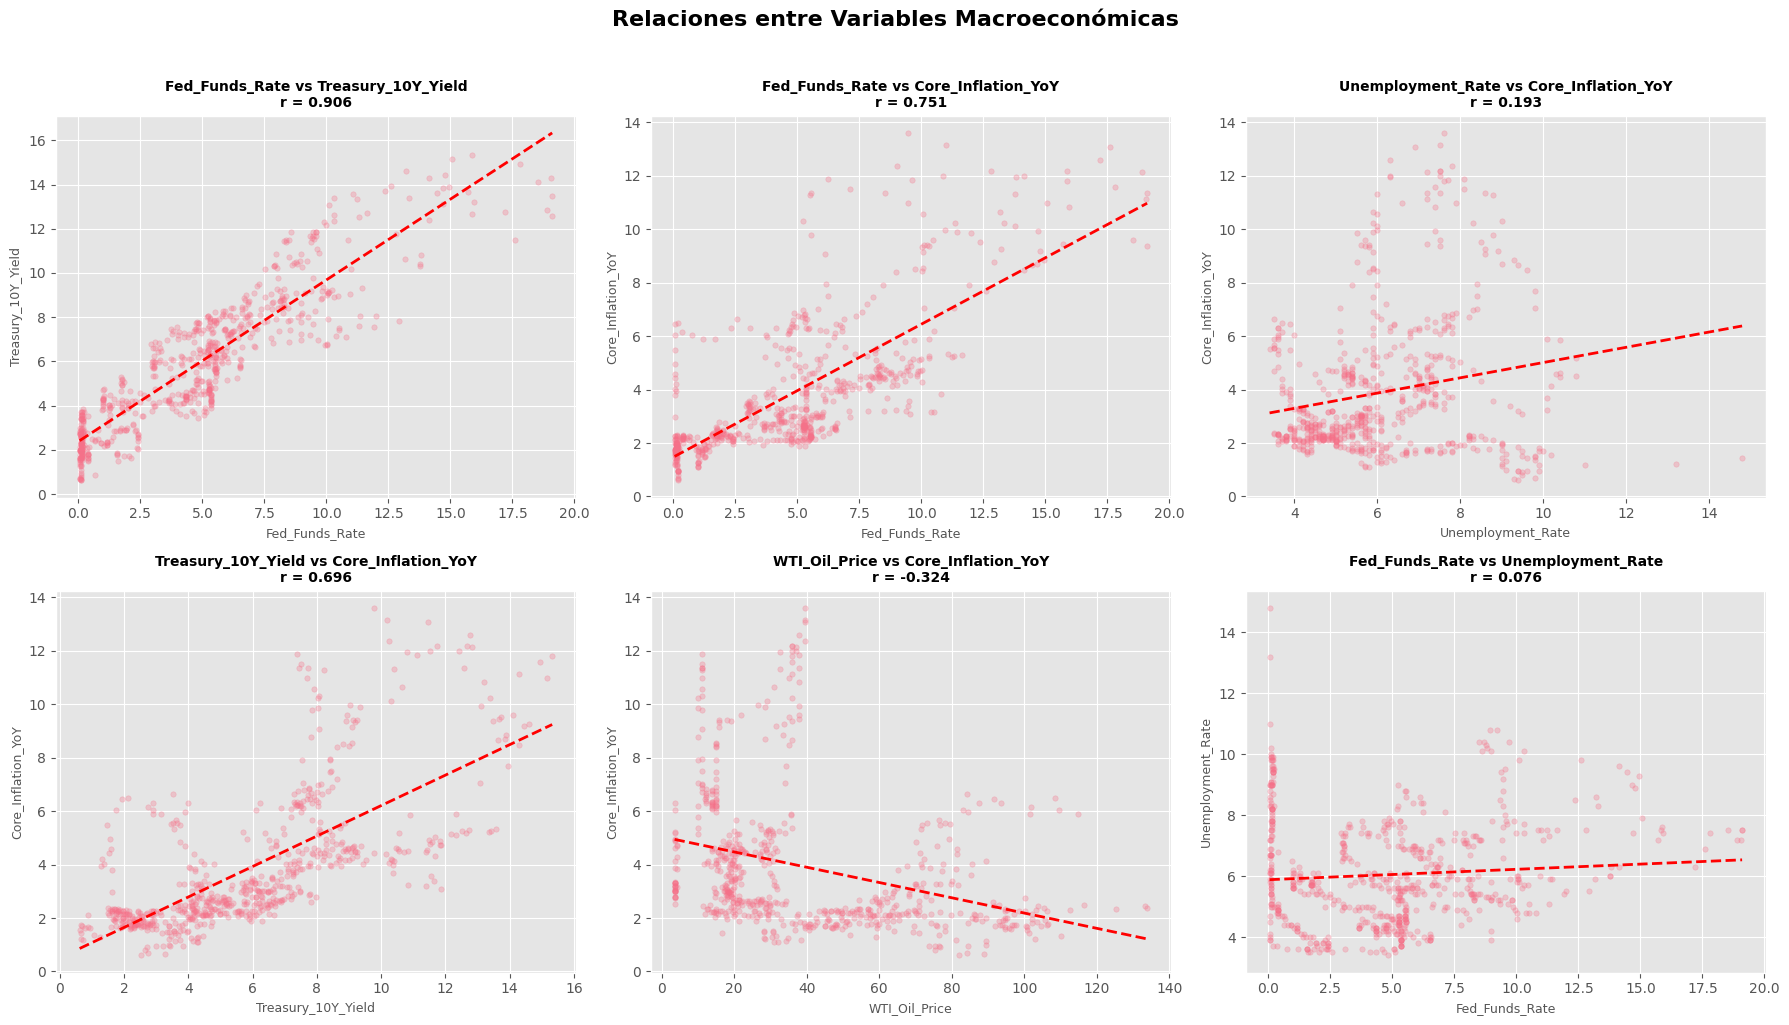

In [41]:
# Scatter plots entre variables macro
macro_pairs = [
    ('Fed_Funds_Rate', 'Treasury_10Y_Yield'),
    ('Fed_Funds_Rate', 'Core_Inflation_YoY'),
    ('Unemployment_Rate', 'Core_Inflation_YoY'),
    ('Treasury_10Y_Yield', 'Core_Inflation_YoY'),
    ('WTI_Oil_Price', 'Core_Inflation_YoY'),
    ('Fed_Funds_Rate', 'Unemployment_Rate'),
]
macro_pairs = [(a, b) for a, b in macro_pairs if a in df_macro_final.columns and b in df_macro_final.columns]

n_mp = len(macro_pairs)
fig, axes = plt.subplots((n_mp + 2) // 3, 3, figsize=(18, 5 * ((n_mp + 2) // 3)))
axes = axes.flatten()

for i, (v1, v2) in enumerate(macro_pairs):
    temp = df_macro_final[[v1, v2]].dropna()
    axes[i].scatter(temp[v1], temp[v2], alpha=0.3, s=15)
    z = np.polyfit(temp[v1], temp[v2], 1)
    p = np.poly1d(z)
    x_line = np.linspace(temp[v1].min(), temp[v1].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r--', lw=2)
    r = temp[v1].corr(temp[v2])
    axes[i].set_xlabel(v1, fontsize=9)
    axes[i].set_ylabel(v2, fontsize=9)
    axes[i].set_title(f'{v1} vs {v2}\nr = {r:.3f}', fontweight='bold', fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Relaciones entre Variables Macroeconómicas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1.4.6 Resumen de Redundancia y Selección de Variables

In [42]:
print('=' * 70)
print('RESUMEN: REDUNDANCIA Y SELECCIÓN DE VARIABLES')
print('=' * 70)

print('\n--- Variables Macro con posible redundancia ---')
if high_corr_macro:
    for v1, v2, r in sorted(high_corr_macro, key=lambda x: abs(x[2]), reverse=True):
        tag = '⚠️  POSIBLE REDUNDANCIA' if abs(r) > 0.8 else 'Relación significativa'
        print(f'  • {v1} ↔ {v2}: r={r:.3f}  → {tag}')
else:
    print('  No se encontraron pares con |r| > 0.6')

print(f'''
Recomendaciones:
  1. Variables con |r| > 0.8 son candidatas a eliminación por multicolinealidad.
  2. Las correlaciones móviles muestran que las relaciones cambian en el tiempo,
     justificando modelos de Deep Learning (LSTM/Transformer) que capturen
     dinámicas temporales no estacionarias.
  3. Las correlaciones contemporáneas (mismo mes) entre macro y retornos son
     típicamente bajas, lo que sugiere que se deben explorar LAGS (retardos)
     de las variables macro como predictores.
  4. Considerar features derivados: cambios mensuales (Δ) de las variables macro,
     no solo niveles.
''')

RESUMEN: REDUNDANCIA Y SELECCIÓN DE VARIABLES

--- Variables Macro con posible redundancia ---
  • Treasury_10Y_Yield ↔ Term_Premium_10Y: r=0.770  → Relación significativa
  • Fed_Funds_Rate ↔ Treasury_10Y_Yield: r=0.762  → Relación significativa

Recomendaciones:
  1. Variables con |r| > 0.8 son candidatas a eliminación por multicolinealidad.
  2. Las correlaciones móviles muestran que las relaciones cambian en el tiempo,
     justificando modelos de Deep Learning (LSTM/Transformer) que capturen
     dinámicas temporales no estacionarias.
  3. Las correlaciones contemporáneas (mismo mes) entre macro y retornos son
     típicamente bajas, lo que sugiere que se deben explorar LAGS (retardos)
     de las variables macro como predictores.
  4. Considerar features derivados: cambios mensuales (Δ) de las variables macro,
     no solo niveles.



## **2. Limpieza de los Datos**
---

La selección de las técnicas de preprocesamiento puede variar en cada conjunto de datos. Recuerde que puede aplicar (no necesariamente todas) las técnicas generales vistas en el curso, dependiendo si está trabajando con imagenes, datos estructurados, textos, etc.

In [43]:
# ============================================================
#  PIPELINE DE PREPROCESAMIENTO — FED Corpus + Market Data
# ============================================================
# Requisitos:  pip install pandas numpy nltk scikit-learn

import re
import unicodedata
import warnings
import numpy as np
import pandas as pd
from datetime import datetime

warnings.filterwarnings("ignore")

# ── NLTK (descarga silenciosa) ──────────────────────────────
import nltk
for pkg in ["punkt", "punkt_tab", "stopwords"]:
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

STOP_EN = set(stopwords.words("english"))


# ============================================================
#  BLOQUE 1 — LIMPIEZA DEL CORPUS FED (texto)
# ============================================================

class FEDCorpusCleaner:
    """Preprocesamiento NLP para comunicados de la Reserva Federal."""

    # Patrones comunes de artefactos en PDFs
    _PDF_ARTIFACTS = re.compile(
        r"(\f|\x0c|"          # saltos de página
        r"\bpage\s+\d+\b|"   # "Page 3"
        r"\b\d+\s*/\s*\d+\b|" # "3 / 5"
        r"-{3,}|"             # líneas divisorias "---"
        r"_{3,})",            # líneas "_____"
        re.IGNORECASE,
    )
    _WHITESPACE = re.compile(r"[ \t]+")
    _MULTI_NL   = re.compile(r"\n{3,}")

    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()

    # ── 1.1  Integridad básica ────────────────────────────────
    def drop_duplicates_and_nulls(self):
        before = len(self.df)
        self.df.drop_duplicates(subset=["url"], inplace=True)
        self.df.dropna(subset=["content"], inplace=True)
        self.df = self.df[self.df["content"].str.strip() != ""]
        print(f"[FED 1.1] Filas eliminadas (dupl/nulos): {before - len(self.df)}")
        return self

    # ── 1.2  Parseo y validación de fecha ────────────────────
    def parse_dates(self):
        self.df["date"] = pd.to_datetime(
            self.df["date"].astype(str), format="%Y%m%d", errors="coerce"
        )
        bad = self.df["date"].isna().sum()
        if bad:
            print(f"[FED 1.2] ⚠  {bad} fechas no parseadas → eliminadas")
            self.df.dropna(subset=["date"], inplace=True)
        self.df.sort_values("date", inplace=True)
        self.df.reset_index(drop=True, inplace=True)
        print(f"[FED 1.2] Rango temporal: {self.df['date'].min().date()} → {self.df['date'].max().date()}")
        return self

    # ── 1.3  Normalización Unicode + minúsculas ───────────────
    def normalize_unicode(self):
        def _norm(t):
            t = unicodedata.normalize("NFKC", t)   # ﬁ → fi, etc.
            t = t.encode("ascii", "ignore").decode() # elimina no-ASCII residual
            return t.lower()
        self.df["content_clean"] = self.df["content"].apply(_norm)
        print("[FED 1.3] Unicode normalizado y texto en minúsculas.")
        return self

    # ── 1.4  Eliminación de artefactos PDF ───────────────────
    def remove_pdf_artifacts(self):
        def _clean(t):
            t = self._PDF_ARTIFACTS.sub(" ", t)
            t = self._WHITESPACE.sub(" ", t)
            t = self._MULTI_NL.sub("\n\n", t)
            return t.strip()
        self.df["content_clean"] = self.df["content_clean"].apply(_clean)
        print("[FED 1.4] Artefactos PDF eliminados.")
        return self

    # ── 1.5  Tokenización + eliminación de stopwords ─────────
    def tokenize_and_remove_stopwords(self):
        def _tok(t):
            tokens = word_tokenize(t)
            tokens = [w for w in tokens if w.isalpha() and w not in STOP_EN]
            return tokens
        self.df["tokens"] = self.df["content_clean"].apply(_tok)
        self.df["token_count"] = self.df["tokens"].apply(len)
        print(f"[FED 1.5] Tokenización completa. "
              f"Tokens promedio/doc: {self.df['token_count'].mean():.0f}")
        return self

    # ── 1.6  Filtrado por longitud mínima ────────────────────
    def filter_short_documents(self, min_tokens: int = 50):
        before = len(self.df)
        self.df = self.df[self.df["token_count"] >= min_tokens].reset_index(drop=True)
        print(f"[FED 1.6] Documentos con < {min_tokens} tokens eliminados: {before - len(self.df)}")
        return self

    def run(self) -> pd.DataFrame:
        print("\n" + "="*55)
        print("  LIMPIEZA CORPUS FED")
        print("="*55)
        (self
         .drop_duplicates_and_nulls()
         .parse_dates()
         .normalize_unicode()
         .remove_pdf_artifacts()
         .tokenize_and_remove_stopwords()
         .filter_short_documents())
        print(f"\n✅ Corpus FED limpio: {len(self.df)} documentos.\n")
        return self.df


# ============================================================
#  BLOQUE 2 — LIMPIEZA DE DATOS DE MERCADO (series de tiempo)
# ============================================================

class MarketDataCleaner:
    """Preprocesamiento para datos financieros multi-ticker (yfinance)."""

    def __init__(self, df: pd.DataFrame):
        # yfinance produce MultiIndex en columnas; lo aplanamos
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = ["_".join(filter(None, c)).strip() for c in df.columns]
        self.df = df.copy()
        self.df.index = pd.to_datetime(self.df.index, errors="coerce")
        self.df.sort_index(inplace=True)

    # ── 2.1  Eliminar columnas totalmente vacías ──────────────
    def drop_empty_columns(self):
        before = self.df.shape[1]
        self.df.dropna(axis=1, how="all", inplace=True)
        print(f"[MKT 2.1] Columnas 100% vacías eliminadas: {before - self.df.shape[1]}")
        return self

    # ── 2.2  Eliminar filas de fin de semana / festivos ───────
    def remove_non_trading_days(self):
        before = len(self.df)
        self.df = self.df[self.df.index.dayofweek < 5]  # 0=lun … 4=vie
        # Elimina filas donde TODOS los valores son NaN (día festivo)
        self.df = self.df[~self.df.isnull().all(axis=1)]
        print(f"[MKT 2.2] Filas no bursátiles eliminadas: {before - len(self.df)}")
        return self

    # ── 2.3  Imputación de valores faltantes ─────────────────
    def impute_missing(self):
        missing_before = self.df.isnull().sum().sum()
        # Forward-fill (precio del día anterior): adecuado para series financieras
        self.df.ffill(inplace=True)
        # Back-fill para huecos al inicio de la serie
        self.df.bfill(inplace=True)
        missing_after = self.df.isnull().sum().sum()
        print(f"[MKT 2.3] Valores faltantes: {missing_before} → {missing_after} "
              f"(imputación forward/backward fill)")
        return self

    # ── 2.4  Detección y filtrado de outliers ────────────────
    def remove_outliers_zscore(self, threshold: float = 5.0):
        """
        Reemplaza con NaN valores con |z-score| > threshold en columnas
        de precio/volumen y los re-imputa.  Un umbral alto (5) sólo
        elimina errores evidentes sin borrar eventos reales del mercado.
        """
        numeric_cols = self.df.select_dtypes(include=[np.number]).columns
        outlier_count = 0
        for col in numeric_cols:
            s = self.df[col]
            z = (s - s.mean()) / (s.std() + 1e-9)
            mask = z.abs() > threshold
            outlier_count += mask.sum()
            self.df.loc[mask, col] = np.nan
        # Re-imputa los huecos generados
        self.df.ffill(inplace=True)
        self.df.bfill(inplace=True)
        print(f"[MKT 2.4] Outliers reemplazados (|z| > {threshold}): {outlier_count}")
        return self

    # ── 2.5  Extracción de columnas 'Close' por ticker ────────
    def extract_close_prices(self) -> pd.DataFrame:
        """Retorna DataFrame sólo con precios de cierre ajustados."""
        close_cols = [c for c in self.df.columns if c.startswith("Close_")
                      or c.lower().startswith("adj close_")]
        if not close_cols:
            close_cols = [c for c in self.df.columns if "close" in c.lower()]
        df_close = self.df[close_cols].copy()
        df_close.columns = [c.replace("Close_", "").replace("Adj Close_", "")
                            for c in df_close.columns]
        print(f"[MKT 2.5] Columnas 'Close' extraídas: {list(df_close.columns)}")
        return df_close

    # ── 2.6  Retornos logarítmicos ───────────────────────────
    def add_log_returns(self, df_close: pd.DataFrame) -> pd.DataFrame:
        df_ret = np.log(df_close / df_close.shift(1)).dropna()
        df_ret.columns = [f"{c}_logret" for c in df_ret.columns]
        print(f"[MKT 2.6] Retornos logarítmicos calculados ({len(df_ret)} filas).")
        return df_ret

    # ── 2.7  Normalización Min-Max para modelos ML/LSTM ──────
    def minmax_normalize(self, df_close: pd.DataFrame) -> pd.DataFrame:
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
        arr = scaler.fit_transform(df_close.values)
        df_norm = pd.DataFrame(arr, index=df_close.index,
                               columns=[f"{c}_norm" for c in df_close.columns])
        print(f"[MKT 2.7] Normalización Min-Max aplicada → rango [0, 1].")
        return df_norm, scaler

    def run(self):
        print("\n" + "="*55)
        print("  LIMPIEZA DATOS DE MERCADO")
        print("="*55)
        (self
         .drop_empty_columns()
         .remove_non_trading_days()
         .impute_missing()
         .remove_outliers_zscore())

        df_close  = self.extract_close_prices()
        df_ret    = self.add_log_returns(df_close)
        df_norm, scaler = self.minmax_normalize(df_close)

        print(f"\n✅ Datos de mercado limpios: {len(self.df)} filas × {self.df.shape[1]} cols.")
        print(f"   Precio cierre:   {df_close.shape}")
        print(f"   Retornos log:    {df_ret.shape}")
        print(f"   Normalizado:     {df_norm.shape}\n")

        return {
            "full":    self.df,
            "close":   df_close,
            "returns": df_ret,
            "norm":    df_norm,
            "scaler":  scaler,
        }


# ============================================================
#  BLOQUE 3 — EJECUCIÓN COMPLETA
# ============================================================

def run_preprocessing(fed_csv: str = "fed_corpus_data.csv",
                      market_csv: str = "market_data.csv"):

    # ── Corpus FED ──────────────────────────────────────────
    try:
        df_fed_raw = pd.read_csv(fed_csv)
        print(f"📂 FED corpus cargado: {len(df_fed_raw)} filas")
        df_fed_clean = FEDCorpusCleaner(df_fed_raw).run()
        df_fed_clean.to_csv("fed_corpus_clean.csv", index=False)
        print("💾 Guardado: fed_corpus_clean.csv\n")
    except FileNotFoundError:
        print(f"⚠️  No se encontró '{fed_csv}'. Ejecuta primero la extracción.\n")
        df_fed_clean = None

    # ── Datos de Mercado ─────────────────────────────────────
    try:
        df_mkt_raw = pd.read_csv(market_csv, header=[0, 1], index_col=0)
        print(f"📂 Market data cargado: {df_mkt_raw.shape}")
        mkt = MarketDataCleaner(df_mkt_raw)
        results = mkt.run()

        results["full"].to_csv("market_data_clean.csv")
        results["close"].to_csv("market_close_prices.csv")
        results["returns"].to_csv("market_log_returns.csv")
        results["norm"].to_csv("market_normalized.csv")

        print("💾 Guardados:")
        print("   market_data_clean.csv")
        print("   market_close_prices.csv")
        print("   market_log_returns.csv")
        print("   market_normalized.csv\n")
    except FileNotFoundError:
        print(f"⚠️  No se encontró '{market_csv}'. Ejecuta primero la extracción.\n")
        results = None

    return df_fed_clean, results


if __name__ == "__main__":
    fed_clean, mkt_results = run_preprocessing()

📂 FED corpus cargado: 43 filas

  LIMPIEZA CORPUS FED
[FED 1.1] Filas eliminadas (dupl/nulos): 0
[FED 1.2] Rango temporal: 2021-01-27 → 2026-04-29
[FED 1.3] Unicode normalizado y texto en minúsculas.
[FED 1.4] Artefactos PDF eliminados.
[FED 1.5] Tokenización completa. Tokens promedio/doc: 497
[FED 1.6] Documentos con < 50 tokens eliminados: 0

✅ Corpus FED limpio: 43 documentos.

💾 Guardado: fed_corpus_clean.csv

📂 Market data cargado: (13680, 45)

  LIMPIEZA DATOS DE MERCADO
[MKT 2.1] Columnas 100% vacías eliminadas: 0
[MKT 2.2] Filas no bursátiles eliminadas: 0
[MKT 2.3] Valores faltantes: 191635 → 0 (imputación forward/backward fill)
[MKT 2.4] Outliers reemplazados (|z| > 5.0): 818
[MKT 2.5] Columnas 'Close' extraídas: ['AGG', 'AMD', 'BNS', 'CM', 'DUK', 'GOOGL', 'JNJ', 'WMT', 'XOM']
[MKT 2.6] Retornos logarítmicos calculados (13679 filas).
[MKT 2.7] Normalización Min-Max aplicada → rango [0, 1].

✅ Datos de mercado limpios: 13680 filas × 45 cols.
   Precio cierre:   (13680, 9)
   R

# **Créditos**
---

* **Profesor:** [Fabio Augusto Gonzalez](https://dis.unal.edu.co/~fgonza/)
* **Asistentes docentes :**
  * [Santiago Toledo Cortés](https://sites.google.com/unal.edu.co/santiagotoledo-cortes/)
* **Diseño de imágenes:**
    - [Mario Andres Rodriguez Triana](https://www.linkedin.com/in/mario-andres-rodriguez-triana-394806145/).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).

**Universidad Nacional de Colombia** - *Facultad de Ingeniería*